In [ ]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
tf.get_logger().setLevel("ERROR")

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/vadym-util/')
sys.path.append('/kaggle/input/cmi-competition-code')

import pandas as pd
import data_utils
import os
import utils
from sklearn.pipeline import Pipeline
from scipy.stats import randint
from skopt.space import Categorical, Integer
from sklearn_genetic.space import Categorical as ECat, Integer as EInt
from sklearn.model_selection import GridSearchCV
from sklearn_genetic import GASearchCV
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.model_selection import GroupKFold
from skopt.space import Categorical, Integer, Real
from sklearn_genetic.space import Categorical as ECat, Integer as EInt, Continuous as EFloat
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import f1_score, make_scorer
import numpy as np

from sklearn.model_selection import KFold
import importlib
warnings.filterwarnings('ignore', module='deap')
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

import utils
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data_folder = data_utils.find_data_root()

raw_train_df  = pd.read_csv(data_folder / 'train.csv')
raw_test_df   = pd.read_csv(data_folder / 'test.csv')
train_demo_df = pd.read_csv(data_folder / 'train_demographics.csv')
test_demo_df  = pd.read_csv(data_folder / 'test_demographics.csv')

temp_calculations_folder_name = 'temp_calculations/'
model_run_folder_name = 'model_runs/'
os.makedirs(temp_calculations_folder_name, exist_ok=True)
os.makedirs(model_run_folder_name, exist_ok=True)

In [ ]:
n_splits = 3
cv = GroupKFold(n_splits=n_splits)
model_target = 'composite_target'

scoring = None

tof_columns = [f'tof_{i}_v{j}' for i in range(1, 6) for j in range(0, 64)]
acc_cols = ['acc_x', 'acc_y', 'acc_z']

pipe_name = "temporal_extractor"
classifier_name = 'CNN_1D'

search_mode = "bayesian"  # grid, random, evolutionary, bayesian

pipe_name = 'temporal_extractor'
candidates = 2
generations = 2
tournament_size = 2
elitism = True
crossover_probability = 0.8
mutation_probability = 0.2

chosen_orientation = None

train_size = 0.2

In [ ]:
train_df = raw_train_df.set_index("row_id").copy(deep=True)

if train_size is None:
    rows = (
        (train_demo_df["adult_child"] == 1)
        & (train_demo_df["sex"] == 1)
        & (train_demo_df["handedness"] == 1)
    )

    ideal_subject_ids = (
        train_demo_df.loc[rows]
        .sort_values("elbow_to_wrist_cm", ascending=False)["subject"]
        .to_list()
    )

    train_sample_df = train_df.loc[
        train_df["subject"].isin(ideal_subject_ids) & (train_df["sequence_type"] == "Target")
    ].copy()  # ← ALREADY HAVE .copy() HERE - GOOD!
    
    test_sample_df = None

elif train_size == 0:
    some_sequences = train_df["sequence_id"].unique()[10:20]

    train_sample_df = train_df.loc[
        train_df["sequence_id"].isin(some_sequences)
    ].copy()  # ← ADD .copy() HERE
    
    test_sample_df = None

else:
    target_df = train_df[train_df["sequence_type"] == "Target"].copy()
    
    train_sample_df, test_sample_df = data_utils.sample_balanced_split(
        target_df,
        train_pct=train_size,
        test_pct=0.2,
    )
    # Make sure both are copies
    train_sample_df = train_sample_df.copy()
    if test_sample_df is not None:
        test_sample_df = test_sample_df.copy()

# NOW it's safe to modify - use .loc to be explicit
train_sample_df.loc[:, "gesture_position"] = train_sample_df["gesture"].str.split(" - ").str[0]
train_sample_df.loc[:, "gesture_action"] = train_sample_df["gesture"].str.split(" - ").str[-1]
train_sample_df.loc[:, "composite_target"] = (
    train_sample_df["orientation"].astype(str) + "_" +
    train_sample_df["gesture_action"] + "_" +
    train_sample_df["phase"]
)
train_sample_df.loc[:, "phase_target"] = train_sample_df["phase"]

if test_sample_df is not None and not test_sample_df.empty:
    test_sample_df.loc[:, "gesture_position"] = test_sample_df["gesture"].str.split(" - ").str[0]
    test_sample_df.loc[:, "gesture_action"] = test_sample_df["gesture"].str.split(" - ").str[-1]
    test_sample_df.loc[:, "composite_target"] = (
        test_sample_df["orientation"].astype(str) + "_" +
        test_sample_df["gesture_action"] + "_" +
        test_sample_df["phase"]
    )
    test_sample_df.loc[:, "phase_target"] = test_sample_df["phase"]

# Apply orientation filter to train only
if chosen_orientation is not None and train_sample_df is not None:
    train_sample_df = train_sample_df.loc[
        train_sample_df["orientation"].isin(chosen_orientation)
    ].copy()

if train_sample_df is not None:
    print(f"Train sequences: {train_sample_df['sequence_id'].nunique()}")
if test_sample_df is not None:
    print(f"Test sequences: {test_sample_df['sequence_id'].nunique()}")

In [ ]:
if search_mode == "bayesian":
    param_space = {
        # --- Preprocessing (locked from best run) ---
        f"{pipe_name}__acc_mode": Categorical(['raw','smoothed', "velocity", 'displacement', 'jerk']),
        f"{pipe_name}__linear_acc_mode": Categorical([None, "baseline"]),
        f"{pipe_name}__use_acc_magnitude": Categorical([False, True]),
        f"{pipe_name}__use_linear_acc_magnitude": Categorical([False, True]),
        f"{pipe_name}__compute_dt": Categorical([False, True]),
        f"{pipe_name}__use_highpass_fallback": Categorical([False, True]),
        f"{pipe_name}__fix_quaternion_sign": Categorical([False, True]),
        f"{pipe_name}__standardize": Categorical([None, "mean_std"]),
        f"{pipe_name}__include_mask": Categorical([False, True]),
        f"{pipe_name}__thm_mode": Categorical(['raw', "diff", "centered", "centered_diff"]),

        # --- Parameters to vary ---
        # Sampling rate: try lower (acts as smoothing) and original
        f"{pipe_name}__sampling_rate": Categorical([10, 15, 20, 25]),

        # Window size: scale with sampling rate
        # At 10Hz: 20-40 frames = 2-4 seconds
        # At 25Hz: 5-15 frames = 0.2-0.6 seconds
        f"{pipe_name}__window_size": Integer(5, 50),

        # Clip value: moderate clipping worked well
        f"{pipe_name}__clip_value": Categorical([20.0, 50.0, 100.0]),

        # Interpolation
        f"{pipe_name}__interp_mode": Categorical([None, "linear"]),

        # Smooth alpha: try a small amount of additional smoothing
        f"{pipe_name}__smooth_alpha": Categorical([None, 0.0, 0.1, 0.2]),

        # Rotation: rot6d worked, but try alternatives at low sampling rate
        f"{pipe_name}__rotation_mode": Categorical(["rot6d", "euler", "delta_euler", "quaternion"]),

        # TOF: pooled_diff worked, try variants
        f"{pipe_name}__tof_mode": Categorical(["pooled", "pooled_diff", "sensor_stats", "pooled_stats"]),
        f"{pipe_name}__tof_fill_mode": Categorical(["nan_interpolate", "far_500"]),

        # --- Classifier ---
        f"{classifier_name}__maxlen": Integer(10, 200),

        f"{classifier_name}__conv_filters": Categorical([
            # Very compact (minimal parameters)
            "32-64-64",
            "32-64-128",
            "48-64-96",
            "64-64-64",      # constant width
            "32-48-64-64",
            "32-64-64-128",

            # Compact but still expressive  
            "48-96-96",
            "64-96-128",
            "48-64-96-128",
            "64-64-128-128",

        # Moderate scale-up
            "128-256-512",
            "128-256-512-512",
            "256-256-512",
            "128-256-384-512",
            "96-192-384-512",

            # Larger capacity
            "256-512-512",
            "256-512-1024",
            "128-256-512-1024",
            "256-512-1024-1024",
            "192-384-768-768",

            # Very large (high capacity)
            "256-512-1024-2048",
            "512-512-1024",
            "384-768-1536-1536",
            "512-1024-1024-2048",
        ]),

        f"{classifier_name}__kernel_sizes": Categorical([
            # Very compact
            "1-3-3",
            "3-3-3",
            "1-1-3-3",
            "3-3-3-3",
            "1-3-5-5",

            # Compact but varied
            "3-3-5",
            "3-5-5",
            "3-3-3-5",
            "3-3-5-5",

            # Moderate large
            "7-7-7",
            "5-7-7",
            "7-7-9",
            "5-7-9-9",
            "7-9-11",

            # Very large (use with caution)
            "9-9-11",
            "7-9-11-13",
            "11-13-15",
            "7-11-15-19",
        ]),

        f"{classifier_name}__pool_sizes": Categorical([
            # Most compact
            "2-2-2",           # pool after every conv layer
            "2-2-2-2",         # for 4-layer nets
            "2-2-2-none",
            "3-3-3",           # larger stride, very aggressive
            "3-2-2",
            # Minimal pooling
            "none-none-none",   # no pooling at all
            "2-none-none",      # pool only at start
            "none-2-none",      # pool only in middle
            "none-none-2",      # pool only at end
            "2-none-2",         # pool at start and end
        ]),

        f"{classifier_name}__dense_units": Categorical([
            "none",
            "64",
            "128",
            "64-32",
            "128-64",
            # Best defaults
            "256",
            "512",
            "256-128",
            "512-256",
            "256-128-64",
            "512-256-128",

            # Progressive (deeper but controlled)
            "128-64",
            "256-128-64",
            "384-192-96",
            "512-256-128-64",
        ]),

        f"{classifier_name}__use_batch_norm": Categorical([False, True]),

        f"{classifier_name}__spatial_dropout": Real(0.0, 0.7),

        f"{classifier_name}__dropout": Real(0.0, 0.6),

        f"{classifier_name}__learning_rate": Real(1e-6, 1e-2, prior="log-uniform"),

        f"{classifier_name}__batch_size": Categorical([8, 16, 32, 64, 128]),

        f"{classifier_name}__epochs": Categorical([80, 120, 150, 200, 250, 300, 400]),

        f"{classifier_name}__patience": Categorical([15, 20, 25, 30]),
    }

elif search_mode == "evolutionary":
    param_space = {
        f"{pipe_name}__acc_mode": ECat(["raw", "smoothed", "velocity", "displacement", "jerk"]),
        f"{pipe_name}__linear_acc_mode": ECat([None, "baseline"]),
        f"{pipe_name}__use_acc_magnitude": ECat([False, True]),
        f"{pipe_name}__use_linear_acc_magnitude": ECat([False, True]),
        f"{pipe_name}__sampling_rate": ECat([20, 25, 50]),
        f"{pipe_name}__compute_dt": ECat([True]),
        f"{pipe_name}__clip_value": ECat([None, 20.0, 50.0, 100.0]),
        f"{pipe_name}__interp_mode": ECat([None, "linear"]),
        f"{pipe_name}__use_highpass_fallback": ECat([True]),
        f"{pipe_name}__window_size": EInt(3, 21),
        f"{pipe_name}__smooth_alpha": ECat([None, 0.2, 0.5, 0.8]),
        f"{pipe_name}__standardize": ECat([None, "mean_std"]),
        f"{pipe_name}__include_mask": ECat([False]),

        f"{pipe_name}__rotation_mode": ECat([None, "quaternion", "euler", "delta_euler", "angular_velocity", "rot6d"]),
        f"{pipe_name}__fix_quaternion_sign": ECat([True, False]),

        f"{pipe_name}__tof_mode": ECat([None, "pooled", "pooled_diff", "sensor_stats", "pooled_stats"]),
        f"{pipe_name}__tof_fill_mode": ECat(["nan_interpolate", "far_255", "far_500"]),
        f"{pipe_name}__thm_mode": ECat([None, "raw", "diff", "centered", "centered_diff"]),

        f"{classifier_name}__maxlen": EInt(16, 160),
        f"{classifier_name}__padding_value": ECat([-999.0]),
        f"{classifier_name}__conv_filters": ECat(["32", "64", "128", "32-64", "64-64", "64-128", "32-64-128", "64-128-128"]),
        f"{classifier_name}__kernel_sizes": ECat(["3", "5", "7", "3-3", "5-5", "3-5-7", "5-7-9"]),
        f"{classifier_name}__pool_sizes": ECat(["none", "2", "none-none", "2-none", "2-2", "none-none-none", "2-none-none", "2-2-none"]),
        f"{classifier_name}__dense_units": ECat(["none", "32", "64", "128", "64-32", "128-64"]),
        f"{classifier_name}__use_batch_norm": ECat([True, False]),
        f"{classifier_name}__spatial_dropout": EFloat(0.0, 0.3),
        f"{classifier_name}__dropout": EFloat(0.0, 0.5),
        f"{classifier_name}__learning_rate": EFloat(1e-4, 2e-3),
        f"{classifier_name}__batch_size": ECat([16, 32, 64]),
        f"{classifier_name}__epochs": ECat([60, 80, 120]),
        f"{classifier_name}__patience": ECat([8, 12, 20]),
    }

elif search_mode == "random":

    param_space = {
        f"{pipe_name}__acc_mode": ["raw", "smoothed", "velocity", "displacement", "jerk"],
        f"{pipe_name}__linear_acc_mode": [None, "baseline"],
        f"{pipe_name}__use_acc_magnitude": [False, True],
        f"{pipe_name}__use_linear_acc_magnitude": [False, True],
        f"{pipe_name}__sampling_rate": [20, 25, 50],
        f"{pipe_name}__compute_dt": [True],
        f"{pipe_name}__clip_value": [None, 20.0, 50.0, 100.0],
        f"{pipe_name}__interp_mode": [None, "linear"],
        f"{pipe_name}__use_highpass_fallback": [True],
        f"{pipe_name}__window_size": randint(3, 22),
        f"{pipe_name}__smooth_alpha": [None, 0.2, 0.5, 0.8],
        f"{pipe_name}__standardize": [None, "mean_std"],
        f"{pipe_name}__include_mask": [False],

        f"{pipe_name}__rotation_mode": [None, "quaternion", "euler", "delta_euler", "angular_velocity", "rot6d"],
        f"{pipe_name}__fix_quaternion_sign": [False, True],

        f"{pipe_name}__tof_mode": [None, "pooled", "pooled_diff", "sensor_stats", "pooled_stats"],
        f"{pipe_name}__tof_fill_mode": ["nan_interpolate", "far_255", "far_500"],
        f"{pipe_name}__thm_mode": [None, "raw", "diff", "centered", "centered_diff"],

        f"{classifier_name}__maxlen": randint(16, 161),
        f"{classifier_name}__padding_value": [-999.0],
        f"{classifier_name}__conv_filters": ["32", "64", "128", "32-64", "64-64", "64-128", "32-64-128", "64-128-128"],
        f"{classifier_name}__kernel_sizes": ["3", "5", "7", "3-3", "5-5", "3-5-7", "5-7-9"],
        f"{classifier_name}__pool_sizes": ["none", "2", "none-none", "2-none", "2-2", "none-none-none", "2-none-none", "2-2-none"],
        f"{classifier_name}__dense_units": ["none", "32", "64", "128", "64-32", "128-64"],
        f"{classifier_name}__use_batch_norm": [True, False],
        f"{classifier_name}__spatial_dropout": uniform(0.0, 0.3),
        f"{classifier_name}__dropout": uniform(0.0, 0.5),
        f"{classifier_name}__learning_rate": loguniform(1e-4, 2e-3),
        f"{classifier_name}__batch_size": [16, 32, 64],
        f"{classifier_name}__epochs": [60, 80, 120],
        f"{classifier_name}__patience": [8, 12, 20],
    }

elif search_mode == "grid":
    
    param_space = {
    # ===== FEATURE EXTRACTOR (temporal_extractor) =====
    f"{pipe_name}__acc_mode": ["velocity"],                    # Proven best
    f"{pipe_name}__linear_acc_mode": ["baseline"],             
    f"{pipe_name}__use_acc_magnitude": [True],                 
    f"{pipe_name}__use_linear_acc_magnitude": [True],          
    f"{pipe_name}__sampling_rate": [10],                       # Preserve temporal detail
    f"{pipe_name}__compute_dt": [True],                        
    f"{pipe_name}__clip_value": [50.0],                        
    f"{pipe_name}__interp_mode": ["linear"],                   
    f"{pipe_name}__use_highpass_fallback": [True],             
    f"{pipe_name}__window_size": [31],                         # Larger context (was 21)
    f"{pipe_name}__smooth_alpha": [0.0],                       # No smoothing preserves high-freq
    f"{pipe_name}__standardize": ["mean_std"],                 
    f"{pipe_name}__include_mask": [False],                     

    f"{pipe_name}__rotation_mode": ["rot6d"],                  # Most expressive (6D continuous)
    # Alternative: ["delta_euler"] also works well
    f"{pipe_name}__fix_quaternion_sign": [True],               

    f"{pipe_name}__tof_mode": ["pooled_diff"],                 
    f"{pipe_name}__tof_fill_mode": ["nan_interpolate"],        
    f"{pipe_name}__thm_mode": ["centered_diff"],               

    # ===== LARGER CNN CLASSIFIER =====
    f"{classifier_name}__maxlen": [100],                       # Longer sequences (was 200)
    f"{classifier_name}__padding_value": [-999.0],             

    # DEEPER + WIDER: Pyramid up to 256 filters
    f"{classifier_name}__conv_filters": ["128-256-256"],       # 3 conv layers, deeper
    f"{classifier_name}__kernel_sizes": ["5-5-5"],             # Larger kernels, consistent
    f"{classifier_name}__pool_sizes": ["2-2-2"],               # Progressive pooling
    
    # Keep minimal dense head (still "none" but with more conv features)
    f"{classifier_name}__dense_units": ["none"],               
    
    f"{classifier_name}__use_batch_norm": [True],              # Critical for deep models
    f"{classifier_name}__spatial_dropout": [0.2],              # Increased for more filters
    f"{classifier_name}__dropout": [0.4],                      # Higher regularization
    
    f"{classifier_name}__learning_rate": [1e-4],               # Lower LR for deeper net
    f"{classifier_name}__batch_size": [16],                    # Keep small for long sequences
    f"{classifier_name}__epochs": [200],                       # More epochs for convergence
    f"{classifier_name}__patience": [25],                      # Patient early stopping
}

In [ ]:
importlib.reload(utils)         

pipeline = Pipeline([
    (pipe_name, utils.SequenceExtractor()),
    (classifier_name, utils.KerasCNN1DSequenceClassifier(
        target=model_target
    )),
])

if search_mode == "bayesian":
    search_obj = BayesSearchCV(
        estimator=pipeline,
        search_spaces=param_space,
        n_iter=candidates,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=3,
        random_state=42,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )

elif search_mode == "random":
    search_obj = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_space,
        n_iter=candidates,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=3,
        random_state=42,
        refit=True,
        return_train_score=True,
        error_score = np.nan
    )

elif search_mode == "evolutionary":
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    
    search_obj = GASearchCV(
        estimator=pipeline,
        cv=cv,
        scoring=scoring,
        param_grid=param_space,
        population_size=candidates,
        generations=generations,
        tournament_size=tournament_size,
        elitism=elitism,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        criteria="max",
        n_jobs=1,
        verbose=True,
        keep_top_k=5,
        return_train_score=True,
        error_score=np.nan
    )

elif search_mode == "grid":
    search_obj = GridSearchCV(
        estimator=pipeline,
        param_grid=param_space,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=3,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )

else:
    raise ValueError("search_mode must be one of: 'bayesian', 'random', 'evolutionary', 'grid'")

In [ ]:
y = train_sample_df[['sequence_id', model_target]]
groups = train_sample_df['sequence_id']

print(f"--- {search_mode} Search ---")
if search_mode == 'evolutionary':
    search_obj.fit(train_sample_df, y)
else:
    search_obj.fit(train_sample_df, y, groups=groups)

In [ ]:
# --- 1. Model Prediction & Evaluation ---
best_model = search_obj.best_estimator_
X_test = test_sample_df.copy()

# Get unique ground truth labels per sequence
y_true_seq = (test_sample_df[['sequence_id', model_target]]
              .drop_duplicates('sequence_id')
              .reset_index(drop=True))

y_pred_seq = best_model.predict(X_test)

# Calculate Accuracy
test_accuracy = accuracy_score(y_true_seq[model_target], y_pred_seq)

print(f"--- Final Test Results ---")
print(f"Best CV Score: {search_obj.best_score_:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_true_seq[model_target], y_pred_seq))

# --- 2. Cleanly Append Test Results to CV Results ---
if hasattr(search_obj, 'cv_results_'):
    # Convert search results to DataFrame
    cv_results_df = pd.DataFrame(search_obj.cv_results_)
    cv_results_df['search_mode'] = search_mode
    cv_results_df['target'] = model_target
    
    # Create a "Final Test" row matching the CV columns
    # We use 'params' to label it and put the accuracy in 'mean_test_score'
    test_result_row = pd.DataFrame({
        'params': ['FINAL_HOLD_OUT_TEST'],
        'mean_test_score': [test_accuracy],
        'std_test_score': [0],
        'rank_test_score': [0]
    })
    
    # Concat results - holes in the table (like split scores) fill with NaN
    final_report_df = pd.concat([cv_results_df, test_result_row], ignore_index=True)
    
    # Save the consolidated report
    file_path = f"{model_run_folder_name}{search_mode}_{classifier_name}_results.csv"
    final_report_df.to_csv(file_path, index=False)
    
    print(f"Results consolidated and saved to: {file_path}")

In [1]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
tf.get_logger().setLevel("ERROR")

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/somemultibranch/')
sys.path.append('/kaggle/input/cmi-competition-code')

import pandas as pd
import data_utils
import os
import utils
from sklearn.pipeline import Pipeline
from scipy.stats import randint
from skopt.space import Categorical, Integer
from sklearn_genetic.space import Categorical as ECat, Integer as EInt
from sklearn.model_selection import GridSearchCV
from sklearn_genetic import GASearchCV
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.model_selection import GroupKFold
from skopt.space import Categorical, Integer, Real
from sklearn_genetic.space import Categorical as ECat, Integer as EInt, Continuous as EFloat
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import f1_score, make_scorer
import numpy as np

from sklearn.model_selection import KFold
import importlib
warnings.filterwarnings('ignore', module='deap')
import utils
from sklearn.metrics import accuracy_score, classification_report

from scipy.spatial.transform import Rotation as R

2026-05-14 20:28:46.338103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778790526.530922      31 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778790526.588965      31 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778790527.065718      31 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778790527.065758      31 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778790527.065761      31 computation_placer.cc:177] computation placer alr

In [2]:
data_folder = data_utils.find_data_root()

raw_train_df  = pd.read_csv(data_folder / 'train.csv')
raw_test_df   = pd.read_csv(data_folder / 'test.csv')
train_demo_df = pd.read_csv(data_folder / 'train_demographics.csv')
test_demo_df  = pd.read_csv(data_folder / 'test_demographics.csv')

temp_calculations_folder_name = 'temp_calculations/'
model_run_folder_name = 'model_runs/'
os.makedirs(temp_calculations_folder_name, exist_ok=True)
os.makedirs(model_run_folder_name, exist_ok=True)

Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data


In [3]:
raw_train_df.head(1)

,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [4]:
n_splits = 3
cv = GroupKFold(n_splits=n_splits)
scoring_metric = 'f1_macro'
model_target = 'gesture_action'

scoring = None

tof_columns = [f'tof_{i}_v{j}' for i in range(1, 6) for j in range(0, 64)]
acc_cols = ['acc_x', 'acc_y', 'acc_z']
rot_cols = ["rot_w", "rot_x", "rot_y", "rot_z"]

pipe_name = "temporal_extractor"
classifier_name = 'multi_branch'

search_mode = "bayesian"  # grid, random, evolutionary, bayesian

pipe_name = 'temporal_extractor'
candidates = 10
generations = 2
tournament_size = 2
elitism = True
crossover_probability = 0.8
mutation_probability = 0.2

chosen_orientation = None

train_size = 0.4

experiment_notes = 'narrowed bayes search'

In [5]:
train_df = raw_train_df.set_index("row_id").copy(deep=True)

# ============================================================
# 1. Handedness correction
# ============================================================

# add handedness without breaking row_id index
train_df["handedness"] = train_df["subject"].map(
    train_demo_df.set_index("subject")["handedness"]
)

# 0 = left-handed, 1 = right-handed
left_handed_mask = train_df["handedness"].eq(0)

# acc_x mirror for left-handed subjects
train_df.loc[left_handed_mask, "acc_x"] *= -1.0

# quaternion correction for left-handed subjects
rot_cols = ["rot_w", "rot_x", "rot_y", "rot_z"]

q_wxyz = train_df.loc[left_handed_mask, rot_cols].to_numpy(dtype=float)

# clean invalid / zero quaternions before scipy
q_wxyz = np.nan_to_num(q_wxyz, nan=0.0, posinf=0.0, neginf=0.0)

norm = np.linalg.norm(q_wxyz, axis=1, keepdims=True)
bad_q = norm.squeeze() == 0

q_wxyz[bad_q] = np.array([1.0, 0.0, 0.0, 0.0])

norm = np.linalg.norm(q_wxyz, axis=1, keepdims=True)
q_wxyz = q_wxyz / norm

# scipy expects xyzw, data is wxyz
q_xyzw = q_wxyz[:, [1, 2, 3, 0]]

euler_xyz = R.from_quat(q_xyzw).as_euler("xyz", degrees=False)

# handedness correction: keep X/roll, flip Y/pitch and Z/yaw
euler_xyz[:, [1, 2]] *= -1.0

q_xyzw_fixed = R.from_euler("xyz", euler_xyz, degrees=False).as_quat()

# convert back xyzw -> wxyz
q_wxyz_fixed = q_xyzw_fixed[:, [3, 0, 1, 2]]

train_df.loc[left_handed_mask, rot_cols] = q_wxyz_fixed

# if angular velocity already exists before SequenceExtractor
if {"ang_vel_x", "ang_vel_y", "ang_vel_z"}.issubset(train_df.columns):
    train_df.loc[left_handed_mask, ["ang_vel_y", "ang_vel_z"]] *= -1.0


# ============================================================
# 2. Upside-down subject fix
# ============================================================

upside_down_mask = train_df["subject"].isin([
    "SUBJ_019262",
    "SUBJ_045235",
])

# acc all axes flipped
train_df.loc[upside_down_mask, ["acc_x", "acc_y", "acc_z"]] *= -1.0

# quaternion xyz flipped, w unchanged
train_df.loc[upside_down_mask, ["rot_x", "rot_y", "rot_z"]] *= -1.0

# if angular velocity already exists before SequenceExtractor
if {"ang_vel_x", "ang_vel_y", "ang_vel_z"}.issubset(train_df.columns):
    train_df.loc[upside_down_mask, ["ang_vel_x", "ang_vel_y", "ang_vel_z"]] *= -1.0


# ============================================================
# 3. Clean helper column and check
# ============================================================

print("left-handed subjects corrected:", train_df.loc[left_handed_mask, "subject"].nunique())
print("left-handed rows corrected:", int(left_handed_mask.sum()))
print("bad/zero quaternions replaced:", int(bad_q.sum()))

print("upside-down subjects corrected:", train_df.loc[upside_down_mask, "subject"].nunique())
print("upside-down rows corrected:", int(upside_down_mask.sum()))

train_df = train_df.drop(columns=["handedness"])

left-handed subjects corrected: 10
left-handed rows corrected: 71352
bad/zero quaternions replaced: 1234
upside-down subjects corrected: 2
upside-down rows corrected: 12257


In [6]:
if train_size is None:
    rows = (
        (train_demo_df["adult_child"] == 1)
        & (train_demo_df["sex"] == 1)
        & (train_demo_df["handedness"] == 1)
    )

    ideal_subject_ids = (
        train_demo_df.loc[rows]
        .sort_values("elbow_to_wrist_cm", ascending=False)["subject"]
        .to_list()
    )

    train_sample_df = train_df.loc[
        train_df["subject"].isin(ideal_subject_ids) & (train_df["sequence_type"] == "Target")
    ].copy()  # ← ALREADY HAVE .copy() HERE - GOOD!
    
    test_sample_df = None

elif train_size == 0:
    some_sequences = train_df["sequence_id"].unique()[10:20]

    train_sample_df = train_df.loc[
        train_df["sequence_id"].isin(some_sequences)
    ].copy()  # ← ADD .copy() HERE
    
    test_sample_df = None

else:
    target_df = train_df[train_df["sequence_type"] == "Target"].copy()
    
    train_sample_df, test_sample_df = data_utils.sample_balanced_split(
        target_df,
        train_pct=train_size,
        test_pct=0.2,
    )
    # Make sure both are copies
    train_sample_df = train_sample_df.copy()
    if test_sample_df is not None:
        test_sample_df = test_sample_df.copy()

# NOW it's safe to modify - use .loc to be explicit
train_sample_df.loc[:, "gesture_position"] = train_sample_df["gesture"].str.split(" - ").str[0]
train_sample_df.loc[:, "gesture_action"] = train_sample_df["gesture"].str.split(" - ").str[-1]
train_sample_df.loc[:, "composite_target"] = (
    train_sample_df["orientation"].astype(str) + "_" +
    train_sample_df["gesture_action"] + "_" +
    train_sample_df["phase"]
)
train_sample_df.loc[:, "phase_target"] = train_sample_df["phase"]

if test_sample_df is not None and not test_sample_df.empty:
    test_sample_df.loc[:, "gesture_position"] = test_sample_df["gesture"].str.split(" - ").str[0]
    test_sample_df.loc[:, "gesture_action"] = test_sample_df["gesture"].str.split(" - ").str[-1]
    test_sample_df.loc[:, "composite_target"] = (
        test_sample_df["orientation"].astype(str) + "_" +
        test_sample_df["gesture_action"] + "_" +
        test_sample_df["phase"]
    )
    test_sample_df.loc[:, "phase_target"] = test_sample_df["phase"]

# Apply orientation filter to train only
if chosen_orientation is not None and train_sample_df is not None:
    train_sample_df = train_sample_df.loc[
        train_sample_df["orientation"].isin(chosen_orientation)
    ].copy()

if train_sample_df is not None:
    print(f"Train sequences: {train_sample_df['sequence_id'].nunique()}")
if test_sample_df is not None:
    print(f"Test sequences: {test_sample_df['sequence_id'].nunique()}")

Train: 1944 seqs | 38.0%
Test:  648 seqs  | 12.7%
Train sequences: 1944
Test sequences: 648


In [7]:
if search_mode == "bayesian":
    param_space = {
        # --- Preprocessing ---
        f"{pipe_name}__acc_mode": Categorical(["raw", 'displacement']),
        f"{pipe_name}__linear_acc_mode": Categorical(["baseline"]),
        f"{pipe_name}__use_acc_magnitude": Categorical([True]),
        f"{pipe_name}__use_linear_acc_magnitude": Categorical([True]),
        f"{pipe_name}__sampling_rate": Categorical([10, 20]),
        f"{pipe_name}__compute_dt": Categorical([True]),
        f"{pipe_name}__clip_value": Categorical([50.0]),
        f"{pipe_name}__interp_mode": Categorical(["linear"]),
        f"{pipe_name}__use_highpass_fallback": Categorical([True]),
        f"{pipe_name}__window_size": Integer(1, 13),
        f"{pipe_name}__smooth_alpha": Categorical([0.5]),
        f"{pipe_name}__standardize": Categorical([ "mean_std"]),
        f"{pipe_name}__include_mask": Categorical([True]),

        f"{pipe_name}__rotation_mode": Categorical(["quaternion"]),
        f"{pipe_name}__fix_quaternion_sign": Categorical([True]),

        f"{pipe_name}__tof_mode": Categorical( ["sensor_stats"]),
        f"{pipe_name}__tof_fill_mode": Categorical(["far_255"]),
        f"{pipe_name}__thm_mode": Categorical(["centered_diff"]),

        # --- Classifier ---
        f"{classifier_name}__maxlen": Categorical([160]),
        f"{classifier_name}__padding_value": Categorical([-999.0]),

        # fusion
        f"{classifier_name}__fusion_mode": Categorical(["bigru"]),
        f"{classifier_name}__attention_heads": Categorical([8]),
        f"{classifier_name}__gru_units": Categorical([160]),

        # per-branch filters (common patterns)
        f"{classifier_name}__branch_filters": [
            # 2. Scale up ACC only
            {"acc": "128-256-256", "rot": "64-64", "tof": "64", "thm": "16"},
            # 4. Deeper ROT as well
            {"acc": "128-256-256", "rot": "64-128", "tof": "64", "thm": "16"},

        ],

        f"{classifier_name}__branch_kernel_sizes": [
            {"acc": "3", "rot": "3", "tof": "3", "thm": "3"},
            {"acc": "3-3", "rot": "3-3", "tof": "3", "thm": "3"},
            {"acc": "5-3", "rot": "5-3", "tof": "5", "thm": "3"},
        ],

        f"{classifier_name}__branch_pool_sizes": [
            {"acc": "none", "rot": "none", "tof": "none", "thm": "none"},
            # {"acc": "2", "rot": "2", "tof": "2", "thm": "2"},  # all pool once
            # {"acc": "2-2", "rot": "2-2", "tof": "2-2", "thm": "2-2"},  # all pool twice
        ],

        # common
        f"{classifier_name}__use_batch_norm": Categorical([True]),
        f"{classifier_name}__spatial_dropout": Real(0.2, 0.4),
        f"{classifier_name}__dense_units": Categorical(["none", "64-32"]),
        f"{classifier_name}__dropout": Real(0.3, 0.5),
        f"{classifier_name}__learning_rate": Real(1e-4, 3.5e-4, prior="log-uniform"),
        f"{classifier_name}__batch_size": Categorical([16]),
        f"{classifier_name}__epochs": Categorical([120]),
        f"{classifier_name}__patience": Categorical([15]),
    }

elif search_mode == "evolutionary":
    param_space = {
        # --- Preprocessing ---
        f"{pipe_name}__acc_mode": ECat(["raw", "smoothed", "velocity", "displacement", "jerk"]),
        f"{pipe_name}__linear_acc_mode": ECat([None, "baseline"]),
        f"{pipe_name}__use_acc_magnitude": ECat([False, True]),
        f"{pipe_name}__use_linear_acc_magnitude": ECat([False, True]),
        f"{pipe_name}__sampling_rate": ECat([20, 25, 50]),
        f"{pipe_name}__compute_dt": ECat([True]),
        f"{pipe_name}__clip_value": ECat([None, 20.0, 50.0, 100.0]),
        f"{pipe_name}__interp_mode": ECat([None, "linear"]),
        f"{pipe_name}__use_highpass_fallback": ECat([True]),
        f"{pipe_name}__window_size": EInt(3, 21),
        f"{pipe_name}__smooth_alpha": ECat([None, 0.2, 0.5, 0.8]),
        f"{pipe_name}__standardize": ECat([None, "mean_std"]),
        f"{pipe_name}__include_mask": ECat([False]),

        f"{pipe_name}__rotation_mode": ECat([None, "quaternion", "euler", "delta_euler", "angular_velocity", "rot6d"]),
        f"{pipe_name}__fix_quaternion_sign": ECat([True, False]),

        f"{pipe_name}__tof_mode": ECat([None, "pooled", "pooled_diff", "sensor_stats", "pooled_stats"]),
        f"{pipe_name}__tof_fill_mode": ECat(["nan_interpolate", "far_255", "far_500"]),
        f"{pipe_name}__thm_mode": ECat([None, "raw", "diff", "centered", "centered_diff"]),

        # --- Classifier ---
        f"{classifier_name}__maxlen": EInt(16, 160),
        f"{classifier_name}__padding_value": ECat([-999.0]),

        # fusion
        f"{classifier_name}__fusion_mode": ECat(["attention", "bigru", "none"]),
        f"{classifier_name}__attention_heads": EInt(2, 8),
        f"{classifier_name}__gru_units": EInt(64, 256),

        # per-branch filters
        f"{classifier_name}__branch_filters": ECat([
            {"acc":"64","rot":"32","tof":"16","thm":"8"},
            {"acc":"64-128","rot":"32-64","tof":"32","thm":"16"},
            {"acc":"64-128-128","rot":"64-64","tof":"64","thm":"16"},
            {"acc":"128","rot":"64","tof":"32","thm":"16"},
        ]),
        f"{classifier_name}__branch_kernel_sizes": ECat([
            {"acc":"3","rot":"3","tof":"3","thm":"3"},
            {"acc":"3-3","rot":"3-3","tof":"3","thm":"3"},
            {"acc":"5-3","rot":"5-3","tof":"5","thm":"3"},
        ]),
        f"{classifier_name}__branch_pool_sizes": ECat([
            {"acc":"none","rot":"none","tof":"none","thm":"none"},
            {"acc":"none-none","rot":"none-none","tof":"none","thm":"none"},
            {"acc":"2-none","rot":"none-none","tof":"none","thm":"none"},
        ]),

        # common
        f"{classifier_name}__use_batch_norm": ECat([True, False]),
        f"{classifier_name}__spatial_dropout": EFloat(0.0, 0.3),
        f"{classifier_name}__dense_units": ECat(["none", "32", "64", "128", "64-32", "128-64"]),
        f"{classifier_name}__dropout": EFloat(0.0, 0.5),
        f"{classifier_name}__learning_rate": EFloat(1e-4, 2e-3),
        f"{classifier_name}__batch_size": ECat([16, 32, 64]),
        f"{classifier_name}__epochs": ECat([60, 80, 120]),
        f"{classifier_name}__patience": ECat([8, 12, 20]),
    }

elif search_mode == "random":
    param_space = {
        # --- Preprocessing ---
        f"{pipe_name}__acc_mode": ["raw", "smoothed", "velocity", "displacement", "jerk"],
        f"{pipe_name}__linear_acc_mode": [None, "baseline"],
        f"{pipe_name}__use_acc_magnitude": [False, True],
        f"{pipe_name}__use_linear_acc_magnitude": [False, True],
        f"{pipe_name}__sampling_rate": [20, 25, 50],
        f"{pipe_name}__compute_dt": [True],
        f"{pipe_name}__clip_value": [None, 20.0, 50.0, 100.0],
        f"{pipe_name}__interp_mode": [None, "linear"],
        f"{pipe_name}__use_highpass_fallback": [True],
        f"{pipe_name}__window_size": randint(3, 22),
        f"{pipe_name}__smooth_alpha": [None, 0.2, 0.5, 0.8],
        f"{pipe_name}__standardize": [None, "mean_std"],
        f"{pipe_name}__include_mask": [False],

        f"{pipe_name}__rotation_mode": [None, "quaternion", "euler", "delta_euler", "angular_velocity", "rot6d"],
        f"{pipe_name}__fix_quaternion_sign": [False, True],

        f"{pipe_name}__tof_mode": [None, "pooled", "pooled_diff", "sensor_stats", "pooled_stats"],
        f"{pipe_name}__tof_fill_mode": ["nan_interpolate", "far_255", "far_500"],
        f"{pipe_name}__thm_mode": [None, "raw", "diff", "centered", "centered_diff"],

        # --- Classifier ---
        f"{classifier_name}__maxlen": randint(16, 161),
        f"{classifier_name}__padding_value": [-999.0],

        # fusion
        f"{classifier_name}__fusion_mode": ["attention", "bigru", "none"],
        f"{classifier_name}__attention_heads": randint(2, 9),
        f"{classifier_name}__gru_units": randint(64, 257),

        # per-branch filters
        f"{classifier_name}__branch_filters": [
            {"acc":"64","rot":"32","tof":"16","thm":"8"},
            {"acc":"64-128","rot":"32-64","tof":"32","thm":"16"},
            {"acc":"64-128-128","rot":"64-64","tof":"64","thm":"16"},
            {"acc":"128","rot":"64","tof":"32","thm":"16"},
        ],
        f"{classifier_name}__branch_kernel_sizes": [
            {"acc":"3","rot":"3","tof":"3","thm":"3"},
            {"acc":"3-3","rot":"3-3","tof":"3","thm":"3"},
            {"acc":"5-3","rot":"5-3","tof":"5","thm":"3"},
        ],
        f"{classifier_name}__branch_pool_sizes": [
            {"acc":"none","rot":"none","tof":"none","thm":"none"},
            {"acc":"none-none","rot":"none-none","tof":"none","thm":"none"},
            {"acc":"2-none","rot":"none-none","tof":"none","thm":"none"},
        ],

        # common
        f"{classifier_name}__use_batch_norm": [True, False],
        f"{classifier_name}__spatial_dropout": uniform(0.0, 0.3),
        f"{classifier_name}__dense_units": ["none", "32", "64", "128", "64-32", "128-64"],
        f"{classifier_name}__dropout": uniform(0.0, 0.5),
        f"{classifier_name}__learning_rate": loguniform(1e-4, 2e-3),
        f"{classifier_name}__batch_size": [16, 32, 64],
        f"{classifier_name}__epochs": [60, 80, 120],
        f"{classifier_name}__patience": [8, 12, 20],
    }

elif search_mode == "grid":
    param_space = {
        # --- Preprocessing (locked to best from previous runs) ---
        f"{pipe_name}__acc_mode": ["raw", "smoothed", "velocity", "displacement", "jerk"],
        f"{pipe_name}__linear_acc_mode": ["baseline"],
        f"{pipe_name}__use_acc_magnitude": [True],
        f"{pipe_name}__use_linear_acc_magnitude": [True],
        f"{pipe_name}__sampling_rate": [100],
        f"{pipe_name}__compute_dt": [True],
        f"{pipe_name}__clip_value": [50.0],
        f"{pipe_name}__interp_mode": ["linear"],
        f"{pipe_name}__use_highpass_fallback": [True],
        f"{pipe_name}__window_size": [50],
        f"{pipe_name}__smooth_alpha": [0.8],
        f"{pipe_name}__standardize": ["mean_std"],
        f"{pipe_name}__include_mask": [False],

        f"{pipe_name}__rotation_mode": ["rot6d"],
        f"{pipe_name}__fix_quaternion_sign": [True],

        f"{pipe_name}__tof_mode": ["pooled_diff"],
        f"{pipe_name}__tof_fill_mode": ["far_255"],
        f"{pipe_name}__thm_mode": ["centered_diff"],

        # --- Classifier (vary architecture only) ---
        f"{classifier_name}__maxlen": [120],
        f"{classifier_name}__padding_value": [-999.0],

        # try each fusion mode
        f"{classifier_name}__fusion_mode": ["attention"],
        f"{classifier_name}__attention_heads": [4],
        f"{classifier_name}__gru_units": [128],

        # try different branch depths
        f"{classifier_name}__branch_filters": [
            # {"acc":"64","rot":"32","tof":"16","thm":"8"},
            # {"acc":"64-128","rot":"32-64","tof":"32","thm":"16"},
            {"acc":"64-128-128","rot":"64-64","tof":"64","thm":"16"},
        ],
        f"{classifier_name}__branch_kernel_sizes": [
            {"acc":"3","rot":"3","tof":"3","thm":"3"},
            # {"acc":"3-3","rot":"3-3","tof":"3","thm":"3"},
        ],
        f"{classifier_name}__branch_pool_sizes": [
            {"acc":"none","rot":"none","tof":"none","thm":"none"},
        ],

        # common
        f"{classifier_name}__use_batch_norm": [True],
        f"{classifier_name}__spatial_dropout": [0.1],
        f"{classifier_name}__dense_units": ["64"],
        f"{classifier_name}__dropout": [0.3],
        f"{classifier_name}__learning_rate": [5e-4],
        f"{classifier_name}__batch_size": [32],
        f"{classifier_name}__epochs": [80],
        f"{classifier_name}__patience": [12],
    }

param_space = utils.prepare_multibranch_param_space(
    param_space,
    search_mode,
    Categorical=Categorical,
    ECat=ECat,
)

In [8]:
importlib.reload(utils)         

pipeline = Pipeline([
    (pipe_name, utils.SequenceExtractor()),   # unchanged
    (classifier_name, utils.KerasMultiBranchClassifier(
        target=model_target,
        fusion_mode="attention",    # or "bigru"
        batch_size=32,
        epochs=80,
        patience=12,
    )),
])

if search_mode == "bayesian":
    search_obj = BayesSearchCV(
        estimator=pipeline,
        search_spaces=param_space,
        n_iter=candidates,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=3,
        random_state=42,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )

elif search_mode == "random":
    search_obj = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_space,
        n_iter=candidates,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=3,
        random_state=42,
        refit=True,
        return_train_score=True,
        error_score = np.nan
    )

elif search_mode == "evolutionary":
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    
    search_obj = GASearchCV(
        estimator=pipeline,
        cv=cv,
        scoring=scoring,
        param_grid=param_space,
        population_size=candidates,
        generations=generations,
        tournament_size=tournament_size,
        elitism=elitism,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        criteria="max",
        n_jobs=1,
        verbose=True,
        keep_top_k=5,
        return_train_score=True,
        error_score=np.nan
    )

elif search_mode == "grid":
    search_obj = GridSearchCV(
        estimator=pipeline,
        param_grid=param_space,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        verbose=4,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )

else:
    raise ValueError("search_mode must be one of: 'bayesian', 'random', 'evolutionary', 'grid'")

In [9]:
y = train_sample_df[['sequence_id', model_target]]
groups = train_sample_df['sequence_id']

print(f"--- {search_mode} Search ---")
if search_mode == 'evolutionary':
    search_obj.fit(train_sample_df, y)
else:
    search_obj.fit(train_sample_df, y, groups=groups)

--- bayesian Search ---
Fitting 3 folds for each of 1 candidates, totalling 3 fits


I0000 00:00:1778790719.866722      31 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778790719.872764      31 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778790729.219718      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


[CV 1/3] END multi_branch__attention_heads=8, multi_branch__batch_size=16, multi_branch__branch_filters={"acc": "128-256-256", "rot": "64-128", "thm": "16", "tof": "64"}, multi_branch__branch_kernel_sizes={"acc": "3", "rot": "3", "thm": "3", "tof": "3"}, multi_branch__branch_pool_sizes={"acc": "none", "rot": "none", "thm": "none", "tof": "none"}, multi_branch__dense_units=none, multi_branch__dropout=0.3701862669798288, multi_branch__epochs=120, multi_branch__fusion_mode=bigru, multi_branch__gru_units=160, multi_branch__learning_rate=0.00019916719468958353, multi_branch__maxlen=160, multi_branch__padding_value=-999.0, multi_branch__patience=15, multi_branch__spatial_dropout=0.21557824582745133, multi_branch__use_batch_norm=True, temporal_extractor__acc_mode=displacement, temporal_extractor__clip_value=50.0, temporal_extractor__compute_dt=True, temporal_extractor__fix_quaternion_sign=True, temporal_extractor__include_mask=True, temporal_extractor__interp_mode=linear, temporal_extractor__

In [10]:
# --- 1. Model Prediction & Evaluation ---
best_model = search_obj.best_estimator_
X_test = test_sample_df.copy()

# Get unique ground truth labels per sequence
y_true_seq = (test_sample_df[['sequence_id', model_target]]
              .drop_duplicates('sequence_id')
              .reset_index(drop=True))

y_pred_seq = best_model.predict(X_test)

# Calculate Accuracy
test_accuracy = accuracy_score(y_true_seq[model_target], y_pred_seq)

print(f"--- Final Test Results ---")
print(f"Best CV Score: {search_obj.best_score_:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_true_seq[model_target], y_pred_seq))

# --- 2. Cleanly Append Test Results to CV Results ---
if hasattr(search_obj, 'cv_results_'):
    # Convert search results to DataFrame
    cv_results_df = pd.DataFrame(search_obj.cv_results_)
    cv_results_df['search_mode'] = search_mode
    cv_results_df['target'] = model_target
    
    # Create a "Final Test" row matching the CV columns
    # We use 'params' to label it and put the accuracy in 'mean_test_score'
    test_result_row = pd.DataFrame({
        'params': ['FINAL_HOLD_OUT_TEST'],
        'mean_test_score': [test_accuracy],
        'std_test_score': [0],
        'rank_test_score': [0],
        'exp_notes': [experiment_notes],
    })
    
    # Concat results - holes in the table (like split scores) fill with NaN
    final_report_df = pd.concat([cv_results_df, test_result_row], ignore_index=True)
    
    # Save the consolidated report
    file_path = f"{model_run_folder_name}{search_mode}_{classifier_name}_results.csv"
    final_report_df.to_csv(file_path, index=False)
    
    print(f"Results consolidated and saved to: {file_path}")

--- Final Test Results ---
Best CV Score: 0.6109
Test Accuracy: 0.6096

Classification Report:
                precision    recall  f1-score   support

   pinch skin       0.57      0.60      0.59       162
    pull hair       0.65      0.80      0.72       243
pull hairline       0.57      0.58      0.57        81
      scratch       0.59      0.35      0.44       162

     accuracy                           0.61       648
    macro avg       0.59      0.58      0.58       648
 weighted avg       0.60      0.61      0.60       648

Results consolidated and saved to: model_runs/bayesian_multi_branch_results.csv


# Multi-Task Hard-Sharing Multi-Branch CNN

Targets:

- `gesture_action` primary head
- `orientation` auxiliary head
- `phase` auxiliary head

Model:

- shared multi-branch CNN backbone
- attention / BiGRU / none fusion
- three task heads
- uncertainty-weighted task losses
- multi-domain sensor extraction
- handedness and upside-down correction inside the pipeline
- optional Kalman / EKF-style smoothing and dead-reckoning features


In [1]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import f1_score, classification_report

try:
    from skopt import BayesSearchCV
    from skopt.space import Categorical, Integer, Real
except Exception:
    print("scikit-optimize is not installed. Bayesian optimization will not be available.")

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/hardsharer/')
sys.path.append('/kaggle/input/cmi-competition-code')

import data_utils
import utils_multitask_hardsharing as utils


In [ ]:
# ============================================================
# Config
# ============================================================

search_mode = "grid"      # "grid" or "bayesian"
random_state = 42
n_splits = 2
n_iter = 10
n_jobs = 1

use_subject_holdout = False
holdout_size = 0.3
train_size = 0.7     # used only when use_subject_holdout=False
chosen_orientation = None

pipe_name = "sequence_builder"
corrector_name = "sensor_corrector"
classifier_name = "classifier"

primary_target = "gesture_action"
orientation_target = "orientation"

# Reuse the existing third "phase" head as a position/location head.
# No utils rewrite needed.
position_target = "gesture_position"
phase_target = position_target

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")


In [3]:
# ============================================================
# Load data
# ============================================================

data_root = data_utils.find_data_root()

raw_train_df = pd.read_csv(data_root / "train.csv")
raw_test_df = pd.read_csv(data_root / "test.csv")
train_demo_df = pd.read_csv(data_root / "train_demographics.csv")
test_demo_df = pd.read_csv(data_root / "test_demographics.csv")

print(raw_train_df.shape)
print(raw_test_df.shape)
print(train_demo_df.shape)
print(test_demo_df.shape)


Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
(574945, 341)
(107, 336)
(81, 8)
(2, 8)


In [4]:
# ============================================================
# Base dataframe + helper targets
# ============================================================

train_df = raw_train_df.set_index("row_id").copy(deep=True)

train_df.loc[:, "gesture_position"] = train_df["gesture"].str.split(" - ").str[0]
train_df.loc[:, "gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df.loc[:, "is_target"] = train_df["sequence_type"].eq("Target").astype(int)
train_df.loc[:, "phase_target"] = train_df["phase"]
train_df.loc[:, "orientation_action"] = train_df["orientation"].astype(str) + "||" + train_df["gesture_action"].astype(str)

print("all sequences:", train_df["sequence_id"].nunique())
print("target sequences:", train_df.loc[train_df["sequence_type"].eq("Target"), "sequence_id"].nunique())
print("gesture_action classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_action"].dropna().unique()))
print("orientation classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "orientation"].dropna().unique()))
print("gesture_position classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_position"].dropna().unique()))
print("full gesture classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture"].dropna().unique()))


all sequences: 8151
target sequences: 5113
gesture_action classes: ['pinch skin', 'pull hair', 'pull hairline', 'scratch']
orientation classes: ['Lie on Back', 'Lie on Side - Non Dominant', 'Seated Lean Non Dom - FACE DOWN', 'Seated Straight']
gesture_position classes: ['Above ear', 'Cheek', 'Eyebrow', 'Eyelash', 'Forehead', 'Neck']
full gesture classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']


In [5]:
# ============================================================
# Split: subject holdout OR old train_size logic
# ============================================================

if use_subject_holdout:
    seq_meta = (
        train_df
        .drop_duplicates("sequence_id")
        [["sequence_id", "subject", "sequence_type", "gesture", "gesture_action", "orientation", "phase"]]
        .reset_index(drop=True)
    )

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=holdout_size,
        random_state=random_state,
    )

    train_seq_idx, holdout_seq_idx = next(
        splitter.split(
            seq_meta,
            y=seq_meta["gesture"],
            groups=seq_meta["subject"],
        )
    )

    train_seq_ids = seq_meta.loc[train_seq_idx, "sequence_id"]
    holdout_seq_ids = seq_meta.loc[holdout_seq_idx, "sequence_id"]

    train_sample_df = train_df.loc[train_df["sequence_id"].isin(train_seq_ids)].copy()
    test_sample_df = train_df.loc[train_df["sequence_id"].isin(holdout_seq_ids)].copy()

else:
    if train_size is None:
        rows = (
            (train_demo_df["adult_child"] == 1)
            & (train_demo_df["sex"] == 1)
            & (train_demo_df["handedness"] == 1)
        )

        ideal_subject_ids = (
            train_demo_df.loc[rows]
            .sort_values("elbow_to_wrist_cm", ascending=False)["subject"]
            .to_list()
        )

        train_sample_df = train_df.loc[
            train_df["subject"].isin(ideal_subject_ids)
            & train_df["sequence_type"].eq("Target")
        ].copy()

        test_sample_df = None

    elif train_size == 0:
        some_sequences = train_df["sequence_id"].unique()[10:20]

        train_sample_df = train_df.loc[
            train_df["sequence_id"].isin(some_sequences)
        ].copy()

        test_sample_df = None

    else:
        target_df = train_df.loc[train_df["sequence_type"].eq("Target")].copy()

        train_sample_df, test_sample_df = data_utils.sample_balanced_split(
            target_df,
            train_pct=train_size,
            test_pct=0.2,
            random_state=random_state,
        )

        train_sample_df = train_sample_df.copy()
        test_sample_df = test_sample_df.copy()

if chosen_orientation is not None:
    train_sample_df = train_sample_df.loc[train_sample_df["orientation"].isin(chosen_orientation)].copy()
    if test_sample_df is not None:
        test_sample_df = test_sample_df.loc[test_sample_df["orientation"].isin(chosen_orientation)].copy()

target_only_train_df = train_sample_df.loc[train_sample_df["sequence_type"].eq("Target")].copy()

target_only_holdout_df = None
if test_sample_df is not None:
    target_only_holdout_df = test_sample_df.loc[test_sample_df["sequence_type"].eq("Target")].copy()

print("use_subject_holdout:", use_subject_holdout)
print("train sequences:", train_sample_df["sequence_id"].nunique())
print("target-only train sequences:", target_only_train_df["sequence_id"].nunique())

if test_sample_df is not None:
    print("holdout/test sequences:", test_sample_df["sequence_id"].nunique())
    print("target-only holdout sequences:", target_only_holdout_df["sequence_id"].nunique())
    print("train subjects:", train_sample_df["subject"].nunique())
    print("holdout subjects:", test_sample_df["subject"].nunique())
    print("subject overlap:", len(set(train_sample_df["subject"]) & set(test_sample_df["subject"])))


Train: 1944 seqs | 38.0%
Test:  648 seqs  | 12.7%
use_subject_holdout: False
train sequences: 1944
target-only train sequences: 1944
holdout/test sequences: 648
target-only holdout sequences: 648
train subjects: 81
holdout subjects: 81
subject overlap: 81


In [6]:
# ============================================================
# Mapping check: orientation + gesture_action -> original gesture
# ============================================================

target_map_df = (
    target_only_train_df
    .drop_duplicates(["orientation", "gesture_action", "gesture"])
    [["orientation", "gesture_action", "gesture"]]
    .copy()
)

mapping_check = (
    target_map_df
    .groupby(["orientation", "gesture_action"])["gesture"]
    .nunique()
    .reset_index(name="n_gesture")
    .sort_values("n_gesture", ascending=False)
)

print(mapping_check.head(20))
print("max mappings per orientation/action:", mapping_check["n_gesture"].max())


                        orientation gesture_action  n_gesture
1                       Lie on Back      pull hair          3
5        Lie on Side - Non Dominant      pull hair          3
13                  Seated Straight      pull hair          3
9   Seated Lean Non Dom - FACE DOWN      pull hair          3
7        Lie on Side - Non Dominant        scratch          2
4        Lie on Side - Non Dominant     pinch skin          2
3                       Lie on Back        scratch          2
0                       Lie on Back     pinch skin          2
15                  Seated Straight        scratch          2
12                  Seated Straight     pinch skin          2
11  Seated Lean Non Dom - FACE DOWN        scratch          2
8   Seated Lean Non Dom - FACE DOWN     pinch skin          2
6        Lie on Side - Non Dominant  pull hairline          1
2                       Lie on Back  pull hairline          1
10  Seated Lean Non Dom - FACE DOWN  pull hairline          1
14      

In [7]:
# ============================================================
# Pipeline
# ============================================================

pipeline = Pipeline([
    (
        corrector_name,
        utils.SensorOrientationCorrector(
            demo_df=train_demo_df,
            apply_handedness=True,
            apply_upside_down=True,
        ),
    ),
    (
        pipe_name,
        utils.AdvancedMultiDomainSequenceExtractor(
            acc_modes=("raw", "velocity", "displacement", "jerk"),
            rotation_modes=("quaternion", "rot6d", "angular_velocity"),
            sampling_rate=10,
            compute_dt=True,
            interp_mode="linear",
            standardize="mean_std",
            tof_mode="pooled_diff",
            tof_fill_mode="nan_interpolate",
            thm_mode="centered_diff",
            use_acc_magnitude=True,
            use_linear_acc_magnitude=True,
            linear_acc_mode="baseline",
            motion_filter_mode=None,
            use_dead_reckoning=False,
        ),
    ),
    (
        classifier_name,
        utils.KerasMultiTaskMultiBranchClassifier(
            gesture_target=primary_target,
            orientation_target=orientation_target,
            phase_target=phase_target,
            maxlen=160,
            branch_filters={"acc": "64-128-256-256", "rot": "64-64", "tof": "64", "thm": "16"},
            branch_kernel_sizes={"acc": "5-5-5-5", "rot": "3-3", "tof": "3", "thm": "3"},
            branch_pool_sizes={"acc": "2-2-none-none", "rot": "none-none", "tof": "none", "thm": "none"},
            fusion_mode="attention",
            attention_heads=4,
            gru_units=170,
            dense_units="64",
            dropout=0.45,
            spatial_dropout=0.1,
            learning_rate=2e-4,
            batch_size=16,
            epochs=140,
            patience=15,
            uncertainty_weighting=False,
            fixed_gesture_weight=1.0,
            fixed_orientation_weight=0.3,
            fixed_phase_weight=1.0,
            verbose=0,
            random_state=random_state,
        ),
    ),
])


In [ ]:
# ============================================================
# Search space
# ============================================================
# ============================================================
# Search space
# ============================================================

if search_mode == "bayesian":
    param_space = {
        # ============================================================
        # Sequence builder / feature extraction
        # ============================================================
        f"{pipe_name}__acc_modes": Categorical(["smoothed|velocity|displacement|jerk"]),
        f"{pipe_name}__rotation_modes": Categorical(["quaternion|euler|rot6d|angular_velocity"]),
        f"{pipe_name}__sampling_rate": Integer(5, 200),
        f"{pipe_name}__interp_mode": Categorical(["ffill"]),
        f"{pipe_name}__standardize": Categorical(["mean_std"]),
        f"{pipe_name}__linear_acc_mode": Categorical(["baseline"]),
        f"{pipe_name}__use_acc_magnitude": Categorical([True]),
        f"{pipe_name}__use_linear_acc_magnitude": Categorical([True]),
        f"{pipe_name}__tof_mode": Categorical([ "pooled_stats"]),
        f"{pipe_name}__tof_fill_mode": Categorical(["far_255"]),
        f"{pipe_name}__thm_mode": Categorical(["centered_diff"]),
        f"{pipe_name}__motion_filter_mode": Categorical(["extended_kalman"]),
        f"{pipe_name}__kalman_process_noise": Real(1e-5, 1e-1, prior="log-uniform"),
        f"{pipe_name}__kalman_measurement_noise": Real(1e-4, 2.0, prior="log-uniform"),
        f"{pipe_name}__use_dead_reckoning": Categorical([True]),
        f"{pipe_name}__clip_value": Categorical([50.0]),
        f"{pipe_name}__window_size": Integer(2, 200),
        f"{pipe_name}__smooth_alpha": Categorical([0.8]),

        # ============================================================
        # Multi-task multi-branch classifier
        # ============================================================
        f"{classifier_name}__maxlen": Integer(10, 300),

        f"{classifier_name}__branch_filters": [
            #{"acc": "256-512-512-512", "rot": "256-512-512-512", "tof": "128", "thm": "32"},
            #{"acc": "256-512-512-512", "rot": "256-512-512-512", "tof": "128-256", "thm": "32"},
            #{"acc": "256-512-512-512", "rot": "256-512-512-512", "tof": "256-256", "thm": "64"},
            #{"acc": "256-512-768-768", "rot": "256-512-512-512", "tof": "128-256", "thm": "32"},
            {"acc": "256-512-512-512", "rot": "256-512-768-768", "tof": "256-256", "thm": "32"},
            # {"acc": "256-512-768-768", "rot": "256-512-768-768", "tof": "256-256-256", "thm": "64"},
            # {"acc": "256-512-1024-1024", "rot": "256-512-768-768", "tof": "256-512-768-768", "thm": "64"},
        ],

        f"{classifier_name}__branch_kernel_sizes": [
            #{"acc": "5-5-5", "rot": "5-5", "tof": "3-3", "thm": "3"},
            {"acc": "5-5-5-5", "rot": "5-5-5-5", "tof": "3-3", "thm": "3"},
           # {"acc": "7-5-5-3", "rot": "5-5-3-3", "tof": "3-3", "thm": "3"},
        ],

        f"{classifier_name}__branch_pool_sizes": [
            {"acc": "none", "rot": "none", "tof": "none", "thm": "none"},
            # {"acc": "2", "rot": "2", "tof": "none", "thm": "none"},
            # {"acc": "2", "rot": "2", "tof": "2", "thm": "none"},
        ],

        f"{classifier_name}__use_batch_norm": Categorical([True]),
        f"{classifier_name}__fusion_mode": Categorical(["attention"]),
        f"{classifier_name}__attention_heads": Integer(10, 100),
        f"{classifier_name}__gru_units": Integer(500, 700),

        f"{classifier_name}__dense_units": Categorical([
            "64"
        ]),

        f"{classifier_name}__dropout": Categorical([0.1]),
        f"{classifier_name}__spatial_dropout": Categorical([0.1]),
        f"{classifier_name}__learning_rate": Real(1e-6, 1e-4, prior="log-uniform"),
        f"{classifier_name}__batch_size": Categorical([32]),
        f"{classifier_name}__epochs": Categorical([100]),
        f"{classifier_name}__patience": Categorical([15]),

        # Multi-task learning
        f"{classifier_name}__uncertainty_weighting": Categorical([False]),
        f"{classifier_name}__fixed_gesture_weight": Categorical([1.0]),
        f"{classifier_name}__fixed_orientation_weight": Categorical([0.3]),
        f"{classifier_name}__fixed_phase_weight": Categorical([1.0]),

        # Augmentation
        f"{classifier_name}__use_mixup": Categorical([False]),
    }
    param_space = utils.prepare_multitask_param_space(
            param_space,
            search_mode,
            Categorical=Categorical,
    )

elif search_mode == "grid":
    
    param_grid = {
    # ============================================================
    # 1. Sequence builder (fixed to known good values)
    # ============================================================
    f"{pipe_name}__acc_modes": [("smoothed", "velocity", "displacement", "jerk")],
    f"{pipe_name}__rotation_modes": [("quaternion", "euler", "rot6d", "angular_velocity")],
    f"{pipe_name}__sampling_rate": [10],               # successful single‑task value
    f"{pipe_name}__interp_mode": ["ffill"],
    f"{pipe_name}__standardize": ["mean_std"],
    f"{pipe_name}__linear_acc_mode": ["baseline"],
    f"{pipe_name}__use_acc_magnitude": [True],
    f"{pipe_name}__use_linear_acc_magnitude": [True],
    f"{pipe_name}__tof_mode": ["pooled_stats"],
    f"{pipe_name}__tof_fill_mode": ["far_255"],
    f"{pipe_name}__thm_mode": ["centered_diff"],
    f"{pipe_name}__motion_filter_mode": ["extended_kalman"],
    # fixed Kalman params from your best Bayesian run
    f"{pipe_name}__kalman_process_noise": [0.031839],
    f"{pipe_name}__kalman_measurement_noise": [0.461918],
    f"{pipe_name}__use_dead_reckoning": [True],
    f"{pipe_name}__clip_value": [50.0],
    f"{pipe_name}__window_size": [66],
    f"{pipe_name}__smooth_alpha": [0.8],

    # ============================================================
    # 2. Multi‑task classifier – architecture & training
    # ============================================================
    # ----- Model size (3 levels, based on single‑task success) -----
    f"{classifier_name}__branch_filters": [
        {"acc": "64-128-128", "rot": "32-64", "tof": "32", "thm": "8"},   # Small
        {"acc": "128-256-256", "rot": "64-128", "tof": "64", "thm": "16"}, # Medium (best single‑task)
        {"acc": "256-512-512", "rot": "128-256", "tof": "128", "thm": "32"}, # Large
    ],
    # ----- Kernel sizes (same pattern as single‑task) -----
    f"{classifier_name}__branch_kernel_sizes": [
        {"acc": "5-3", "rot": "5-3", "tof": "5", "thm": "3"}
    ],
    # ----- No pooling – keep time dims equal -----
    f"{classifier_name}__branch_pool_sizes": [
        {"acc": "none", "rot": "none", "tof": "none", "thm": "none"}
    ],

    # ----- Fusion -----
    f"{classifier_name}__fusion_mode": ["attention"],
    f"{classifier_name}__gru_units": [160],      # only used if fusion_mode='bigru'
    f"{classifier_name}__attention_heads": [12],    # only used if fusion_mode='attention'

    # ----- Regularisation -----
    f"{classifier_name}__dropout": [0.01],
    f"{classifier_name}__spatial_dropout": [0.01],
    f"{classifier_name}__use_batch_norm": [True],

    # ----- Training hyperparameters -----
    f"{classifier_name}__learning_rate": [1e-4],
    f"{classifier_name}__batch_size": [32],
    f"{classifier_name}__epochs": [100],
    f"{classifier_name}__patience": [20],
    f"{classifier_name}__dense_units": ["64"],        # one dense layer before heads

    # ----- Multi‑task weighting (keep orientation weight low) -----
    f"{classifier_name}__uncertainty_weighting": [False],
    f"{classifier_name}__fixed_gesture_weight": [1.0],
    f"{classifier_name}__fixed_orientation_weight": [0.3],
    f"{classifier_name}__fixed_phase_weight": [1.0],

    # ----- Augmentation (turn off for now – add later if needed) -----
    f"{classifier_name}__use_mixup": [False],
    f"{classifier_name}__use_gaussian_noise": [False],
    f"{classifier_name}__use_magnitude_scaling": [False],
    f"{classifier_name}__use_time_mask": [False],
    f"{classifier_name}__use_time_shift": [False],
    f"{classifier_name}__use_channel_dropout": [False],
    f"{classifier_name}__use_modality_dropout": [False],
}

In [9]:
# ============================================================
# CV search
# ============================================================

cv = GroupKFold(n_splits=n_splits)

groups = target_only_train_df["subject"]
X_train = target_only_train_df.copy()
y_train = target_only_train_df[["sequence_id", primary_target, orientation_target, phase_target]].copy()

if search_mode == "bayesian":
    if BayesSearchCV is None:
        raise ImportError("skopt is not installed. Use search_mode='grid' or install scikit-optimize.")

    search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=param_space,
        n_iter=n_iter,
        cv=cv,
        scoring=None,
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=3,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )
else:
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_space,
        cv=cv,
        scoring=None,
        n_jobs=n_jobs,
        verbose=4,
        refit=True,
        return_train_score=True,
        error_score=np.nan
    )

search.fit(X_train, y_train, groups=groups)

print("best gesture macro F1:", search.best_score_)
print("best params:")
print(search.best_params_)


Fitting 2 folds for each of 1 candidates, totalling 2 fits


I0000 00:00:1779903435.761219      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779903435.767289      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779903446.675939      70 service.cc:152] XLA service 0x7a324c003150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779903446.675973      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779903446.675976      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779903448.595064      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-27 17:37:33.812099: E external/local_xla/xla/service/slow_operation

[CV 1/2] END classifier__attention_heads=47, classifier__batch_size=32, classifier__branch_filters={"acc": "256-512-512-512", "rot": "256-512-768-768", "thm": "32", "tof": "256-256"}, classifier__branch_kernel_sizes={"acc": "5-5-5-5", "rot": "5-5-5-5", "thm": "3", "tof": "3-3"}, classifier__branch_pool_sizes={"acc": "none", "rot": "none", "thm": "none", "tof": "none"}, classifier__dense_units=64, classifier__dropout=0.1, classifier__epochs=100, classifier__fixed_gesture_weight=1.0, classifier__fixed_orientation_weight=0.3, classifier__fixed_phase_weight=1.0, classifier__fusion_mode=attention, classifier__gru_units=536, classifier__learning_rate=1.8373473033929418e-05, classifier__maxlen=33, classifier__patience=15, classifier__spatial_dropout=0.1, classifier__uncertainty_weighting=False, classifier__use_batch_norm=True, classifier__use_mixup=False, sequence_builder__acc_modes=smoothed|velocity|displacement|jerk, sequence_builder__clip_value=50.0, sequence_builder__interp_mode=ffill, se

2026-05-27 18:54:53.386274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 18:54:53.727051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[CV 1/2] END classifier__attention_heads=82, classifier__batch_size=32, classifier__branch_filters={"acc": "256-512-512-512", "rot": "256-512-768-768", "thm": "32", "tof": "256-256"}, classifier__branch_kernel_sizes={"acc": "5-5-5-5", "rot": "5-5-5-5", "thm": "3", "tof": "3-3"}, classifier__branch_pool_sizes={"acc": "none", "rot": "none", "thm": "none", "tof": "none"}, classifier__dense_units=64, classifier__dropout=0.1, classifier__epochs=100, classifier__fixed_gesture_weight=1.0, classifier__fixed_orientation_weight=0.3, classifier__fixed_phase_weight=1.0, classifier__fusion_mode=attention, classifier__gru_units=551, classifier__learning_rate=3.3859441208872077e-06, classifier__maxlen=88, classifier__patience=15, classifier__spatial_dropout=0.1, classifier__uncertainty_weighting=False, classifier__use_batch_norm=True, classifier__use_mixup=False, sequence_builder__acc_modes=smoothed|velocity|displacement|jerk, sequence_builder__clip_value=50.0, sequence_builder__interp_mode=ffill, se

2026-05-27 19:06:40.321966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 19:06:40.648887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[CV 2/2] END classifier__attention_heads=82, classifier__batch_size=32, classifier__branch_filters={"acc": "256-512-512-512", "rot": "256-512-768-768", "thm": "32", "tof": "256-256"}, classifier__branch_kernel_sizes={"acc": "5-5-5-5", "rot": "5-5-5-5", "thm": "3", "tof": "3-3"}, classifier__branch_pool_sizes={"acc": "none", "rot": "none", "thm": "none", "tof": "none"}, classifier__dense_units=64, classifier__dropout=0.1, classifier__epochs=100, classifier__fixed_gesture_weight=1.0, classifier__fixed_orientation_weight=0.3, classifier__fixed_phase_weight=1.0, classifier__fusion_mode=attention, classifier__gru_units=551, classifier__learning_rate=3.3859441208872077e-06, classifier__maxlen=88, classifier__patience=15, classifier__spatial_dropout=0.1, classifier__uncertainty_weighting=False, classifier__use_batch_norm=True, classifier__use_mixup=False, sequence_builder__acc_modes=smoothed|velocity|displacement|jerk, sequence_builder__clip_value=50.0, sequence_builder__interp_mode=ffill, se

2026-05-27 20:22:13.148084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 20:22:13.502702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[CV 1/2] END classifier__attention_heads=59, classifier__batch_size=32, classifier__branch_filters={"acc": "256-512-512-512", "rot": "256-512-768-768", "thm": "32", "tof": "256-256"}, classifier__branch_kernel_sizes={"acc": "5-5-5-5", "rot": "5-5-5-5", "thm": "3", "tof": "3-3"}, classifier__branch_pool_sizes={"acc": "none", "rot": "none", "thm": "none", "tof": "none"}, classifier__dense_units=64, classifier__dropout=0.1, classifier__epochs=100, classifier__fixed_gesture_weight=1.0, classifier__fixed_orientation_weight=0.3, classifier__fixed_phase_weight=1.0, classifier__fusion_mode=attention, classifier__gru_units=638, classifier__learning_rate=1.4195928013966814e-06, classifier__maxlen=90, classifier__patience=15, classifier__spatial_dropout=0.1, classifier__uncertainty_weighting=False, classifier__use_batch_norm=True, classifier__use_mixup=False, sequence_builder__acc_modes=smoothed|velocity|displacement|jerk, sequence_builder__clip_value=50.0, sequence_builder__interp_mode=ffill, se

In [10]:
# ============================================================
# Save CV results
# ============================================================

cv_results_df = pd.DataFrame(search.cv_results_)
cv_path = results_dir / f"{search_mode}_multitask_hardsharing_cv_results_{timestamp}.csv"
cv_results_df.to_csv(cv_path, index=False)

best_params_path = results_dir / f"{search_mode}_multitask_hardsharing_best_params_{timestamp}.json"
with open(best_params_path, "w") as f:
    json.dump(search.best_params_, f, indent=2, default=str)

print(cv_path)
print(best_params_path)


results/bayesian_multitask_hardsharing_cv_results_20260527_1734.csv
results/bayesian_multitask_hardsharing_best_params_20260527_1734.json


In [11]:
# ============================================================
# Holdout evaluation with valid orientation/action/position decoding
# ============================================================

best_model = search.best_estimator_

if target_only_holdout_df is not None and not target_only_holdout_df.empty:
    X_holdout = target_only_holdout_df.copy()

    holdout_seq = (
        X_holdout
        .drop_duplicates("sequence_id")
        [["sequence_id", primary_target, orientation_target, position_target, "gesture"]]
        .reset_index(drop=True)
    )

    X_holdout_features = best_model[:-1].transform(X_holdout)
    clf = best_model.named_steps[classifier_name]

    pred_df = clf.predict_all(X_holdout_features)

    pred_df = pred_df.rename(
        columns={
            "phase_pred": "gesture_position_pred"
        }
    )

    proba = clf.predict_proba(X_holdout_features)

    orientation_proba_df = pd.DataFrame(
        proba["orientation"],
        columns=clf.orientation_classes_,
    )

    action_proba_df = pd.DataFrame(
        proba["gesture"],
        columns=clf.gesture_classes_,
    )

    position_proba_df = pd.DataFrame(
        proba["phase"],
        columns=clf.phase_classes_,
    )

    valid_table = (
        train_df.loc[
            train_df["sequence_type"].eq("Target"),
            ["orientation", "gesture", "gesture_action", "gesture_position"]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    eps = 1e-9
    decoded_gestures = []

    for i in range(len(pred_df)):
        scores = []

        for _, row in valid_table.iterrows():
            ori = row["orientation"]
            act = row["gesture_action"]
            pos = row["gesture_position"]

            score = (
                np.log(orientation_proba_df.loc[i, ori] + eps)
                + np.log(action_proba_df.loc[i, act] + eps)
                + np.log(position_proba_df.loc[i, pos] + eps)
            )

            scores.append(score)

        decoded_gestures.append(
            valid_table.iloc[int(np.argmax(scores))]["gesture"]
        )

    holdout_pred = pd.concat(
        [
            holdout_seq.reset_index(drop=True),
            pred_df.reset_index(drop=True),
        ],
        axis=1,
    )

    holdout_pred["raw_reconstructed_gesture_pred"] = (
        holdout_pred["gesture_position_pred"].astype(str)
        + " - "
        + holdout_pred["gesture_action_pred"].astype(str)
    )

    holdout_pred["valid_decoded_gesture_pred"] = decoded_gestures

    gesture_action_f1 = f1_score(
        holdout_pred[primary_target],
        holdout_pred["gesture_action_pred"],
        average="macro",
    )

    gesture_position_f1 = f1_score(
        holdout_pred[position_target],
        holdout_pred["gesture_position_pred"],
        average="macro",
    )

    orientation_f1 = f1_score(
        holdout_pred[orientation_target],
        holdout_pred["orientation_pred"],
        average="macro",
    )

    raw_reconstructed_gesture_f1 = f1_score(
        holdout_pred["gesture"],
        holdout_pred["raw_reconstructed_gesture_pred"],
        average="macro",
    )

    valid_decoded_gesture_f1 = f1_score(
        holdout_pred["gesture"],
        holdout_pred["valid_decoded_gesture_pred"],
        average="macro",
    )

    print("holdout gesture_action macro F1:", round(gesture_action_f1, 4))
    print("holdout gesture_position macro F1:", round(gesture_position_f1, 4))
    print("holdout orientation macro F1:", round(orientation_f1, 4))
    print("holdout raw reconstructed gesture macro F1:", round(raw_reconstructed_gesture_f1, 4))
    print("holdout valid decoded gesture macro F1:", round(valid_decoded_gesture_f1, 4))

    print("\nGesture action report")
    print(classification_report(
        holdout_pred[primary_target],
        holdout_pred["gesture_action_pred"],
    ))

    print("\nGesture position report")
    print(classification_report(
        holdout_pred[position_target],
        holdout_pred["gesture_position_pred"],
    ))

    print("\nOrientation report")
    print(classification_report(
        holdout_pred[orientation_target],
        holdout_pred["orientation_pred"],
    ))

    print("\nRaw reconstructed full gesture report")
    print(classification_report(
        holdout_pred["gesture"],
        holdout_pred["raw_reconstructed_gesture_pred"],
    ))

    print("\nValid decoded full gesture report")
    print(classification_report(
        holdout_pred["gesture"],
        holdout_pred["valid_decoded_gesture_pred"],
    ))

    holdout_path = results_dir / f"multitask_position_holdout_predictions_{timestamp}.csv"
    summary_path = results_dir / f"multitask_position_holdout_summary_{timestamp}.csv"

    holdout_pred.to_csv(holdout_path, index=False)

    pd.DataFrame([
        {
            "search_mode": search_mode,
            "best_cv_gesture_action_macro_f1": search.best_score_,
            "holdout_gesture_action_macro_f1": gesture_action_f1,
            "holdout_gesture_position_macro_f1": gesture_position_f1,
            "holdout_orientation_macro_f1": orientation_f1,
            "holdout_raw_reconstructed_gesture_macro_f1": raw_reconstructed_gesture_f1,
            "holdout_valid_decoded_gesture_macro_f1": valid_decoded_gesture_f1,
            "n_train_sequences": target_only_train_df["sequence_id"].nunique(),
            "n_holdout_sequences": target_only_holdout_df["sequence_id"].nunique(),
        }
    ]).to_csv(summary_path, index=False)

    print(holdout_path)
    print(summary_path)

else:
    print("No target-only holdout dataframe available. Skipping holdout evaluation.")

holdout gesture_action macro F1: 0.5674
holdout gesture_position macro F1: 0.5524
holdout orientation macro F1: 0.9315
holdout raw reconstructed gesture macro F1: 0.1912
holdout valid decoded gesture macro F1: 0.4803

Gesture action report
               precision    recall  f1-score   support

   pinch skin       0.61      0.40      0.48       162
    pull hair       0.66      0.74      0.70       243
pull hairline       0.52      0.56      0.54        81
      scratch       0.53      0.58      0.55       162

     accuracy                           0.59       648
    macro avg       0.58      0.57      0.57       648
 weighted avg       0.59      0.59      0.59       648


Gesture position report
              precision    recall  f1-score   support

   Above ear       0.89      0.51      0.65        81
       Cheek       0.47      0.43      0.45        81
     Eyebrow       0.34      0.27      0.30        81
     Eyelash       0.43      0.37      0.40        81
    Forehead       0.

In [12]:
# ============================================================
# Inspect task setup
# ============================================================

clf = search.best_estimator_.named_steps[classifier_name]

print("gesture target:", clf.gesture_target)
print("orientation target:", clf.orientation_target)
print("third head target:", clf.phase_target)

print("uncertainty weighting:", clf.uncertainty_weighting)
print("fixed gesture weight:", clf.fixed_gesture_weight)
print("fixed orientation weight:", clf.fixed_orientation_weight)
print("fixed position/phase weight:", clf.fixed_phase_weight)

if hasattr(clf, "gesture_classes_"):
    print("\ngesture_action classes:")
    print(clf.gesture_classes_)

if hasattr(clf, "orientation_classes_"):
    print("\norientation classes:")
    print(clf.orientation_classes_)

if hasattr(clf, "phase_classes_"):
    print("\ngesture_position classes:")
    print(clf.phase_classes_)

gesture target: gesture_action
orientation target: orientation
third head target: gesture_position
uncertainty weighting: False
fixed gesture weight: 1.0
fixed orientation weight: 0.3
fixed position/phase weight: 1.0

gesture_action classes:
['pinch skin' 'pull hair' 'pull hairline' 'scratch']

orientation classes:
['Lie on Back' 'Lie on Side - Non Dominant'
 'Seated Lean Non Dom - FACE DOWN' 'Seated Straight']

gesture_position classes:
['Above ear' 'Cheek' 'Eyebrow' 'Eyelash' 'Forehead' 'Neck']


# Prototypical Networks — Few-Shot Gesture Classification

Implements the **N-way K-shot Prototypical Network** from Snell et al. 2017,  
as covered in Stanford CS330 Lecture 6 (Non-Parametric Few-Shot Learning).

Architecture mirrors the existing `KerasMultiBranchClassifier` backbone —  
multi-branch 1D CNN + attention fusion — but **without a classification head**.  
Instead a projection to an L2-normalised embedding space is appended.  
Classification is done at inference time via nearest-prototype Euclidean distance.

**Key design choices**  
- No inner-loop gradient steps (unlike MAML) — just a forward pass per episode  
- Permutation-invariant prototype computation (mean over support embeddings)  
- Fixed Euclidean distance metric; the encoder learns the metric space  
- Gradient batching over `batch_episodes` episodes before each optimiser step  
- Early stopping on episodic validation accuracy


In [1]:
import os
import warnings
import logging
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

import sys
sys.path.append('/kaggle/input/datasets/keithmarange/protostuffaha/')
sys.path.append('/kaggle/input/cmi-competition-code')

import data_utils
import utils_multitask_hardsharing as utils  # existing pipeline utils
import utils_proto                           # Prototypical Network utils


2026-05-31 16:00:25.162831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780243225.578963      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780243225.706817      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780243226.769488      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780243226.769525      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780243226.769528      23 computation_placer.cc:177] computation placer alr

## Config

In [2]:
random_state    = 42
primary_target  = "gesture"

# Episode hyperparameters
N_WAY           = 4     # number of classes per episode (set to your gesture count)
K_SHOT          = 5     # support examples per class
N_QUERY         = 5     # query examples per class
EPISODES_PER_EPOCH = 200
META_EPOCHS     = 100
PATIENCE        = 10
LEARNING_RATE   = 1e-6
BATCH_EPISODES  = 4     # gradient accumulation over this many episodes

# Encoder
MAXLEN          = 160
EMBED_DIM       = 255
FUSION_MODE     = "attention"  # "attention" | "bigru" | "none"

# Train/val/test split
VAL_FRACTION    = 0.15
TEST_FRACTION   = 0.15

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M")


## Load data

In [3]:
data_root = data_utils.find_data_root()

raw_train_df   = pd.read_csv(data_root / "train.csv")
train_demo_df  = pd.read_csv(data_root / "train_demographics.csv")

print("raw_train_df :", raw_train_df.shape)
print("train_demo_df:", train_demo_df.shape)


Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
raw_train_df : (574945, 341)
train_demo_df: (81, 8)


## Build labels DataFrame

In [4]:
# ============================================================
# Base dataframe + helper targets
# ============================================================

train_df = raw_train_df.set_index("row_id").copy(deep=True)

train_df.loc[:, "gesture_position"] = train_df["gesture"].str.split(" - ").str[0]
train_df.loc[:, "gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df.loc[:, "is_target"] = train_df["sequence_type"].eq("Target").astype(int)
train_df.loc[:, "phase_target"] = train_df["phase"]
train_df.loc[:, "orientation_action"] = train_df["orientation"].astype(str) + "||" + train_df["gesture_action"].astype(str)

print("all sequences:", train_df["sequence_id"].nunique())
print("target sequences:", train_df.loc[train_df["sequence_type"].eq("Target"), "sequence_id"].nunique())
print("gesture_action classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_action"].dropna().unique()))
print("orientation classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "orientation"].dropna().unique()))
print("gesture_position classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_position"].dropna().unique()))
print("full gesture classes:", sorted(train_df.loc[train_df["sequence_type"].eq("Target"), "gesture"].dropna().unique()))


all sequences: 8151
target sequences: 5113
gesture_action classes: ['pinch skin', 'pull hair', 'pull hairline', 'scratch']
orientation classes: ['Lie on Back', 'Lie on Side - Non Dominant', 'Seated Lean Non Dom - FACE DOWN', 'Seated Straight']
gesture_position classes: ['Above ear', 'Cheek', 'Eyebrow', 'Eyelash', 'Forehead', 'Neck']
full gesture classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']


## Subject-aware train / val / test split

Split at **subject level** so no subject leaks across folds.

In [5]:
# ============================================================
# Create label_df (one row per sequence with labels)
# ============================================================

# Create sequence-level metadata with labels
label_df = (
    train_df
    .drop_duplicates("sequence_id")
    [[
        "sequence_id", 
        "subject",           # Note: your column might be "subject" not "subject_id"
        "sequence_type",
        "gesture", 
        "gesture_action", 
        "gesture_position", 
        "orientation",
        "is_target"
    ]]
    .reset_index(drop=True)
    .copy()
)

# Rename if your column is "subject" (not "subject_id")
# If your column is actually "subject_id", change the column name above

print(f"label_df shape: {label_df.shape}")
print(f"Unique sequences: {label_df['sequence_id'].nunique()}")
print(f"Unique subjects: {label_df['subject'].nunique()}")

label_df shape: (8151, 8)
Unique sequences: 8151
Unique subjects: 81


In [6]:
# ============================================================
# Subject-based split
# ============================================================

TEST_FRACTION = 0.15   # 15% for test
VAL_FRACTION = 0.15    # 15% for validation

all_sequence_ids = label_df["sequence_id"].unique()

# Map sequence_id to subject (using the label_df)
seq_to_subject = dict(zip(label_df["sequence_id"], label_df["subject"]))

subjects = [seq_to_subject[sid] for sid in all_sequence_ids]

rng = np.random.default_rng(random_state)
unique_subjects = np.unique(subjects)
rng.shuffle(unique_subjects)

n_test = max(1, int(len(unique_subjects) * TEST_FRACTION))
n_val  = max(1, int(len(unique_subjects) * VAL_FRACTION))

test_subjects  = set(unique_subjects[:n_test])
val_subjects   = set(unique_subjects[n_test : n_test + n_val])
train_subjects = set(unique_subjects[n_test + n_val :])

# Get sequence IDs for each split
train_seq_ids = label_df[label_df["subject"].isin(train_subjects)]["sequence_id"].values
val_seq_ids   = label_df[label_df["subject"].isin(val_subjects)]["sequence_id"].values
test_seq_ids  = label_df[label_df["subject"].isin(test_subjects)]["sequence_id"].values

print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects: {len(val_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"Train seqs: {len(train_seq_ids)}")
print(f"Val seqs: {len(val_seq_ids)}")
print(f"Test seqs: {len(test_seq_ids)}")

Train subjects: 57
Val subjects: 12
Test subjects: 12
Train seqs: 5704
Val seqs: 1223
Test seqs: 1224


## Feature extraction

Uses the same `SequenceExtractor` pipeline as the existing multi-task notebook.

In [7]:
pipe = Pipeline([
    ("sequence_builder", utils.AdvancedMultiDomainSequenceExtractor(
        acc_mode="raw",
        rotation_mode="quaternion",
        linear_acc_mode="baseline",
        use_acc_magnitude=True,
        tof_mode="pooled",
        thm_mode="centered",
        standardize="mean_std",
        # maxlen=MAXLEN,
        sequence_col="sequence_id",
    )),
])

# Fit on ALL training rows then transform each split
train_rows = raw_train_df[raw_train_df["sequence_id"].isin(train_seq_ids)]
val_rows   = raw_train_df[raw_train_df["sequence_id"].isin(val_seq_ids)]
test_rows  = raw_train_df[raw_train_df["sequence_id"].isin(test_seq_ids)]

pipe.fit(train_rows, label_df)

X_train_feat = pipe.transform(train_rows)
X_val_feat   = pipe.transform(val_rows)
X_test_feat  = pipe.transform(test_rows)

print("X_train_feat:", X_train_feat.shape, "| index=sequence_id")
print("X_val_feat  :", X_val_feat.shape)
print("X_test_feat :", X_test_feat.shape)


X_train_feat: (403044, 61) | index=sequence_id
X_val_feat  : (83034, 61)
X_test_feat : (88867, 61)


## Label DataFrames per split

In [8]:
y_train = label_df[label_df["sequence_id"].isin(train_seq_ids)].copy()
y_val   = label_df[label_df["sequence_id"].isin(val_seq_ids)].copy()
y_test  = label_df[label_df["sequence_id"].isin(test_seq_ids)].copy()

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


y_train: (5704, 8)
y_val  : (1223, 8)
y_test : (1224, 8)


## Build & meta-train the Prototypical Network

In [9]:
proto_clf = utils_proto.KerasPrototypicalClassifier(
    target=primary_target,
    maxlen=MAXLEN,
    padding_value=-999.0,

    # Encoder architecture (matches KerasMultiBranchClassifier defaults)
    branch_filters=       {"acc": "512-512-512", "rot": "512-512-512", "tof": "256", "thm": "64"},
    branch_kernel_sizes=  {"acc": "3-3-3",    "rot": "3-3-3",   "tof": "3",  "thm": "3"},
    branch_pool_sizes=    {"acc": "2-2", "rot": "2-2", "tof": "2", "thm": "none"},
    fusion_mode=FUSION_MODE,
    attention_heads=10,
    gru_units=128,
    use_batch_norm=True,
    spatial_dropout=0.01,
    embed_dim=EMBED_DIM,
    dropout=0.01,

    # Episode hyperparameters
    n_way=N_WAY,
    k_shot=K_SHOT,
    n_query=N_QUERY,
    episodes_per_epoch=EPISODES_PER_EPOCH,
    meta_epochs=META_EPOCHS,
    patience=PATIENCE,
    learning_rate=LEARNING_RATE,
    batch_episodes=BATCH_EPISODES,
    val_fraction=VAL_FRACTION,
    verbose=1,
    random_state=random_state,
)


In [10]:
proto_clf.fit(X_train_feat, y_train)
print(f"\nBest episodic val accuracy: {proto_clf.best_val_acc_:.4f}")


I0000 00:00:1780243400.388681      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780243400.394583      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780243402.750009      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch   1/100  train_loss=1.2954  train_acc=0.4888  val_loss=1.3021  val_acc=0.4500
Epoch   2/100  train_loss=1.2758  train_acc=0.5175  val_loss=1.2483  val_acc=0.5580
Epoch   3/100  train_loss=1.2610  train_acc=0.5350  val_loss=1.2131  val_acc=0.5880
Epoch   4/100  train_loss=1.2368  train_acc=0.5618  val_loss=1.2069  val_acc=0.5830
Epoch   5/100  train_loss=1.2342  train_acc=0.5543  val_loss=1.1922  val_acc=0.5850
Epoch   6/100  train_loss=1.2057  train_acc=0.5823  val_loss=1.1747  val_acc=0.5620
Epoch   7/100  train_loss=1.1824  train_acc=0.6042  val_loss=1.1634  val_acc=0.5850
Epoch   8/100  train_loss=1.1757  train_acc=0.5870  val_loss=1.1452  val_acc=0.6030
Epoch   9/100  train_loss=1.1464  train_acc=0.6155  val_loss=1.1611  val_acc=0.5520
Epoch  10/100  train_loss=1.1397  train_acc=0.6160  val_loss=1.1431  val_acc=0.5790
Epoch  11/100  train_loss=1.1447  train_acc=0.6075  val_loss=1.1117  val_acc=0.6200
Epoch  12/100  train_loss=1.1241  train_acc=0.6162  val_loss=1.1190  val_acc

## Training curves

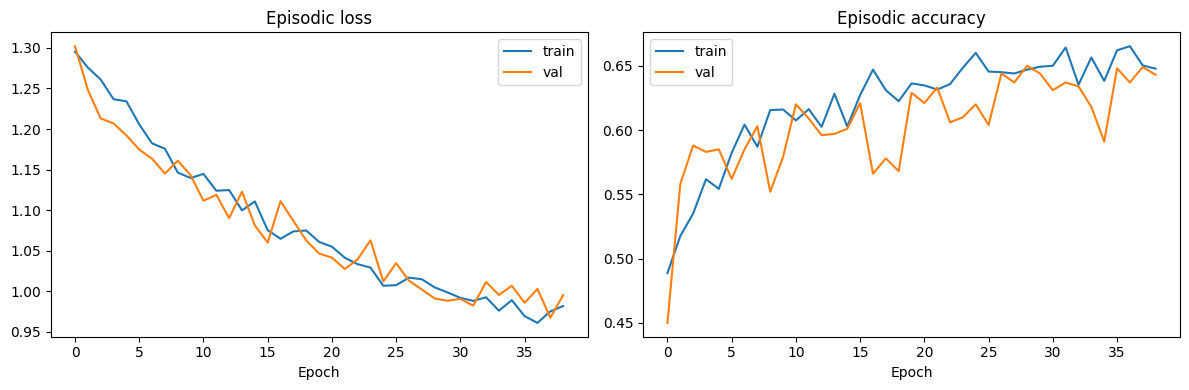

In [11]:
import matplotlib.pyplot as plt

hist = proto_clf.history_
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["train_loss"], label="train")
axes[0].plot(hist["val_loss"],   label="val")
axes[0].set_title("Episodic loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist["train_acc"], label="train")
axes[1].plot(hist["val_acc"],   label="val")
axes[1].set_title("Episodic accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(results_dir / f"proto_training_curves_{timestamp}.png", dpi=120)
plt.show()


## Evaluation on held-out test set

**Prototypical inference** requires a support set.  
We use the **validation set** as the support set and the test set as queries.  
This mirrors the meta-test setup from CS330 Lecture 6:

```
compute prototypes from support set → classify queries by nearest prototype
```


In [12]:
# Build prototypes from validation support set
proto_clf.fit_support(X_val_feat, y_val)

# Predict on test queries
y_pred_test = proto_clf.predict(X_test_feat)

# Ground-truth labels (one per test sequence)
X_test_pad, test_seq_ids = proto_clf._pad(X_test_feat)
y_test_seq = proto_clf._collapse_y(test_seq_ids, y_test)

f1_macro = f1_score(y_test_seq, y_pred_test, average="macro")
print(f"Test macro-F1: {f1_macro:.4f}")
print()
print(classification_report(y_test_seq, y_pred_test))


I0000 00:00:1780247028.498411      71 service.cc:152] XLA service 0x7bfca71a63c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780247028.498482      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780247028.498488      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780247030.250856      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test macro-F1: 0.2443

                                            precision    recall  f1-score   support

                     Above ear - pull hair       0.17      0.18      0.18        96
                        Cheek - pinch skin       0.15      0.42      0.22        96
                     Drink from bottle/cup       0.36      0.75      0.49        24
                       Eyebrow - pull hair       0.00      0.00      0.00        96
                       Eyelash - pull hair       0.20      0.01      0.02        96
Feel around in tray and pull out an object       0.45      0.79      0.58        24
                  Forehead - pull hairline       0.44      0.19      0.26        96
                        Forehead - scratch       0.26      0.45      0.33        96
                            Glasses on/off       0.12      0.25      0.16        24
                         Neck - pinch skin       0.20      0.19      0.19        96
                            Neck - scratch       0.2

## K-shot ablation

One of the key benefits of Prototypical Networks is that you can vary K at inference time  
without retraining — the encoder is fixed; only the prototype computation changes.


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

le = proto_clf.le_
y_val_enc = le.transform(proto_clf._collapse_y(
    proto_clf._pad(X_val_feat)[1], y_val
))

X_val_pad, val_seq_ids = proto_clf._pad(X_val_feat)
val_embeddings = proto_clf.encoder_.predict(X_val_pad, verbose=0)

results_kshot = {}
for k in [1, 2, 5, 10, "all"]:
    if k == "all":
        sub_emb = val_embeddings
        sub_labels = y_val_enc
    else:
        rng_k = np.random.default_rng(42)
        sub_idx = []
        for cls in range(len(proto_clf.classes_)):
            cls_idx = np.flatnonzero(y_val_enc == cls)
            chosen = rng_k.choice(cls_idx, size=min(k, len(cls_idx)), replace=False)
            sub_idx.extend(chosen.tolist())
        sub_emb    = val_embeddings[sub_idx]
        sub_labels = y_val_enc[sub_idx]

    proto_clf.prototypes_ = proto_clf._compute_prototypes(sub_emb, sub_labels)

    y_pred_k = proto_clf.predict(X_test_feat)
    f1_k = f1_score(y_test_seq, y_pred_k, average="macro")
    results_kshot[k] = f1_k
    print(f"K={str(k):>4}  macro-F1 = {f1_k:.4f}")

# Restore full support
proto_clf.fit_support(X_val_feat, y_val)


K=   1  macro-F1 = 0.1870
K=   2  macro-F1 = 0.1604
K=   5  macro-F1 = 0.2230
K=  10  macro-F1 = 0.2602
K= all  macro-F1 = 0.2443


KerasPrototypicalClassifier(attention_heads=10,
                            branch_filters={'acc': '512-512-512',
                                            'rot': '512-512-512', 'thm': '64',
                                            'tof': '256'},
                            branch_kernel_sizes={'acc': '3-3-3', 'rot': '3-3-3',
                                                 'thm': '3', 'tof': '3'},
                            branch_pool_sizes={'acc': '2-2', 'rot': '2-2',
                                               'thm': 'none', 'tof': '2'},
                            dropout=0.01, embed_dim=255, learning_rate=1e-06,
                            maxlen=160, meta_epochs=100, spatial_dropout=0.01,
                            target='gesture')

## Embedding space visualisation (UMAP)

If `umap-learn` is not available this cell is skipped.

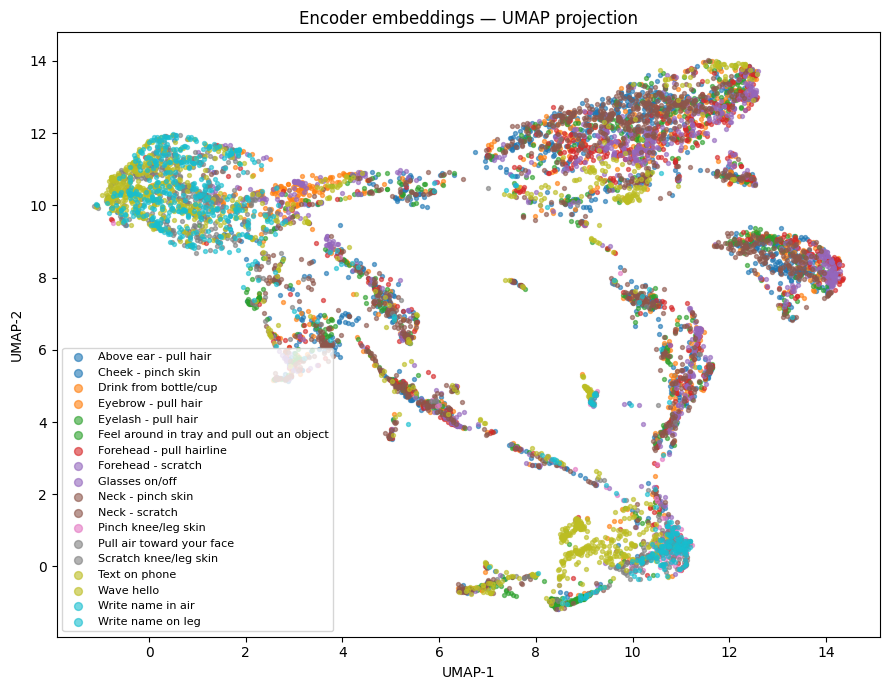

In [14]:
try:
    import umap

    X_all_pad, all_seq_ids = proto_clf._pad(
        pd.concat([X_train_feat, X_val_feat, X_test_feat])
    )
    all_emb = proto_clf.encoder_.predict(X_all_pad, verbose=0)

    all_y = pd.concat([
        proto_clf._collapse_y(proto_clf._pad(X_train_feat)[1], y_train),
        proto_clf._collapse_y(proto_clf._pad(X_val_feat)[1],   y_val),
        proto_clf._collapse_y(proto_clf._pad(X_test_feat)[1],  y_test),
    ]).reset_index(drop=True)

    reducer = umap.UMAP(n_components=2, random_state=random_state, n_neighbors=15)
    emb_2d  = reducer.fit_transform(all_emb)

    classes_unique = proto_clf.classes_
    cmap = plt.cm.get_cmap("tab10", len(classes_unique))

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, cls in enumerate(classes_unique):
        mask = all_y == cls
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   s=8, alpha=0.6, color=cmap(i), label=cls)
    ax.legend(markerscale=2, fontsize=8)
    ax.set_title("Encoder embeddings — UMAP projection")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.tight_layout()
    plt.savefig(results_dir / f"proto_umap_{timestamp}.png", dpi=120)
    plt.show()

except ImportError:
    print("umap-learn not installed — skipping visualisation. pip install umap-learn")


## Save encoder weights

In [15]:
weights_path = results_dir / f"proto_encoder_{timestamp}.weights.h5"
proto_clf.encoder_.save_weights(str(weights_path))
print(f"Encoder weights saved to {weights_path}")

# Save label encoder classes for later inference
np.save(
    results_dir / f"proto_classes_{timestamp}.npy",
    proto_clf.classes_,
)
print("Label encoder classes saved.")


Encoder weights saved to results/proto_encoder_20260531_1600.weights.h5
Label encoder classes saved.


# Three-Model Hierarchical CNN Experiment

Plain CNN only. No multibranch classifier params.

Hierarchy:

1. `is_target`: Target vs Non-Target
2. `orientation`: trained on Target sequences only
3. `gesture_action`: trained on Target sequences only

Final compressed hierarchy label:

- Target rows: reconstructed original `gesture` using `(orientation, gesture_action)` lookup
- Non-Target rows: `Non-Target`

This is designed to test whether the hierarchy improves the target-gesture path before adding a separate non-target classifier.

In [1]:
from __future__ import annotations

import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix

try:
    from skopt import BayesSearchCV
    from skopt.space import Categorical, Integer, Real
except Exception as exc:
    BayesSearchCV = None
    Categorical = None
    Integer = None
    Real = None
    print("BayesSearchCV unavailable. Use search_mode='grid'.", exc)

import data_utils
import utils_hierarchical_cnn_aug as utils

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# ============================================================
# Config
# ============================================================

search_mode = "grid"      # "grid" or "bayesian"
random_state = 42
holdout_size = 0.2
n_cv_splits = 3
n_iter_bayes = 12
n_jobs = 1

pipe_name = "sequence_builder"
classifier_name = "classifier"
corrector_name = "orientation_corrector"

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
print("timestamp:", timestamp)

timestamp: 20260515_0158


In [3]:
# ============================================================
# Load data
# ============================================================

data_root = data_utils.find_data_root()

raw_train_df = pd.read_csv(data_root / "train.csv")
raw_test_df = pd.read_csv(data_root / "test.csv")
train_demo_df = pd.read_csv(data_root / "train_demographics.csv")
test_demo_df = pd.read_csv(data_root / "test_demographics.csv")

print("raw_train_df:", raw_train_df.shape)
print("train_demo_df:", train_demo_df.shape)
print("train sequences:", raw_train_df["sequence_id"].nunique())
print("subjects:", raw_train_df["subject"].nunique())

Using local data folder: C:\Users\maran\OneDrive\Documents\Git Profile\cmi_dexter\data
raw_train_df: (574945, 341)
train_demo_df: (81, 8)
train sequences: 8151
subjects: 81


In [4]:
# ============================================================
# Base dataframe + helper targets
# ============================================================

train_df = raw_train_df.set_index("row_id").copy(deep=True)

train_df.loc[:, "gesture_position"] = train_df["gesture"].str.split(" - ").str[0]
train_df.loc[:, "gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df.loc[:, "is_target"] = train_df["sequence_type"].eq("Target").astype(int)

train_df.loc[:, "hierarchical_gesture"] = np.where(
    train_df["sequence_type"].eq("Target"),
    train_df["gesture"],
    "Non-Target",
)

train_df.loc[:, "orientation_action"] = (
    train_df["orientation"].astype(str)
    + "||"
    + train_df["gesture_action"].astype(str)
)

seq_counts = (
    train_df
    .drop_duplicates("sequence_id")
    ["hierarchical_gesture"]
    .value_counts()
)

display(seq_counts.head(30))
print("hierarchical classes:", train_df["hierarchical_gesture"].nunique())
print("gesture_action classes:", train_df.loc[train_df["sequence_type"].eq("Target"), "gesture_action"].nunique())
print("orientation classes:", train_df.loc[train_df["sequence_type"].eq("Target"), "orientation"].nunique())

hierarchical_gesture
Non-Target                  3038
Eyelash - pull hair          640
Forehead - pull hairline     640
Neck - scratch               640
Neck - pinch skin            640
Forehead - scratch           640
Eyebrow - pull hair          638
Above ear - pull hair        638
Cheek - pinch skin           637
Name: count, dtype: int64

hierarchical classes: 9
gesture_action classes: 4
orientation classes: 4


In [5]:
# ============================================================
# Mapping check: orientation + gesture_action -> original gesture
# ============================================================

target_map_df = (
    train_df
    .loc[train_df["sequence_type"].eq("Target")]
    .drop_duplicates(["orientation", "gesture_action", "gesture"])
    [["orientation", "gesture_action", "gesture"]]
    .copy()
)

mapping_check = (
    target_map_df
    .groupby(["orientation", "gesture_action"])["gesture"]
    .nunique()
    .reset_index(name="n_gesture_labels")
)

display(mapping_check.sort_values("n_gesture_labels", ascending=False).head(20))
print("all mappings unique:", mapping_check["n_gesture_labels"].eq(1).all())

target_lookup = {
    (row.orientation, row.gesture_action): row.gesture
    for row in target_map_df.itertuples(index=False)
}

most_common_target_gesture = (
    train_df
    .loc[train_df["sequence_type"].eq("Target")]
    .drop_duplicates("sequence_id")
    ["gesture"]
    .mode()
    .iloc[0]
)

print("target lookup size:", len(target_lookup))
print("fallback target gesture:", most_common_target_gesture)

,orientation,gesture_action,n_gesture_labels
1,Lie on Back,pull hair,3
5,Lie on Side - Non Dominant,pull hair,3
13,Seated Straight,pull hair,3
9,Seated Lean Non Dom - FACE DOWN,pull hair,3
7,Lie on Side - Non Dominant,scratch,2
4,Lie on Side - Non Dominant,pinch skin,2
3,Lie on Back,scratch,2
0,Lie on Back,pinch skin,2
15,Seated Straight,scratch,2
12,Seated Straight,pinch skin,2


all mappings unique: False
target lookup size: 16
fallback target gesture: Eyelash - pull hair


In [6]:
# ============================================================
# Subject holdout split
# ============================================================

seq_meta = (
    train_df
    .drop_duplicates("sequence_id")
    [["sequence_id", "subject", "sequence_type", "gesture", "hierarchical_gesture"]]
    .reset_index(drop=True)
)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=holdout_size,
    random_state=random_state,
)

train_seq_idx, holdout_seq_idx = next(
    splitter.split(
        seq_meta,
        y=seq_meta["hierarchical_gesture"],
        groups=seq_meta["subject"],
    )
)

train_seq_ids = seq_meta.loc[train_seq_idx, "sequence_id"]
holdout_seq_ids = seq_meta.loc[holdout_seq_idx, "sequence_id"]

train_model_df = train_df.loc[train_df["sequence_id"].isin(train_seq_ids)].copy()
holdout_df = train_df.loc[train_df["sequence_id"].isin(holdout_seq_ids)].copy()

target_only_train_df = train_model_df.loc[train_model_df["sequence_type"].eq("Target")].copy()
target_only_holdout_df = holdout_df.loc[holdout_df["sequence_type"].eq("Target")].copy()

print("train sequences:", train_model_df["sequence_id"].nunique())
print("holdout sequences:", holdout_df["sequence_id"].nunique())
print("target-only train sequences:", target_only_train_df["sequence_id"].nunique())
print("target-only holdout sequences:", target_only_holdout_df["sequence_id"].nunique())
print("train subjects:", train_model_df["subject"].nunique())
print("holdout subjects:", holdout_df["subject"].nunique())
print("subject overlap:", len(set(train_model_df["subject"]) & set(holdout_df["subject"])))

train sequences: 6422
holdout sequences: 1729
target-only train sequences: 4025
target-only holdout sequences: 1088
train subjects: 64
holdout subjects: 17
subject overlap: 0


In [ ]:
# ============================================================
# Common plain-CNN param options
# No multibranch params here.
# ============================================================

if search_mode == "bayesian":
    assert BayesSearchCV is not None, "BayesSearchCV is not available. Set search_mode='grid'."

    target_param_space = {
        f"{pipe_name}__acc_modes": Categorical([
            ("raw",),
            ("raw", "velocity"),
            ("raw", "velocity", "displacement"),
        ]),
        f"{pipe_name}__linear_acc_mode": Categorical([None, "baseline"]),
        f"{pipe_name}__use_acc_magnitude": Categorical([True]),
        f"{pipe_name}__use_linear_acc_magnitude": Categorical([False, True]),
        f"{pipe_name}__sampling_rate": Categorical([20, 25, 50]),
        f"{pipe_name}__clip_value": Categorical([None, 20.0, 50.0]),
        f"{pipe_name}__interp_mode": Categorical([None, "linear"]),
        f"{pipe_name}__window_size": Integer(3, 21),
        f"{pipe_name}__smooth_alpha": Categorical([None, 0.5, 0.8]),
        f"{pipe_name}__standardize": Categorical(["mean_std"]),
        f"{pipe_name}__rotation_modes": Categorical([
            ("quaternion",),
            ("rot6d",),
            ("quaternion", "rot6d"),
        ]),
        f"{pipe_name}__tof_mode": Categorical([None, "sensor_stats"]),
        f"{pipe_name}__tof_fill_mode": Categorical(["nan_interpolate", "far_255"]),
        f"{pipe_name}__thm_mode": Categorical([None, "centered"]),

        f"{classifier_name}__maxlen": Integer(32, 160),
        f"{classifier_name}__conv_filters": Categorical(["64", "128", "128-256", "128-256-256"]),
        f"{classifier_name}__kernel_sizes": Categorical(["3", "5", "3-3", "5-5", "5-5-5"]),
        f"{classifier_name}__pool_sizes": Categorical(["none", "2", "2-2", "2-2-2"]),
        f"{classifier_name}__use_batch_norm": Categorical([True]),
        f"{classifier_name}__spatial_dropout": Real(0.0, 0.5),
        f"{classifier_name}__dense_units": Categorical(["16", "32", "64", "128"]),
        f"{classifier_name}__dropout": Real(0.0, 0.6),
        f"{classifier_name}__learning_rate": Real(1e-6, 2e-3, prior="log-uniform"),
        f"{classifier_name}__batch_size": Categorical([32, 64]),
        f"{classifier_name}__epochs": Categorical([80, 120, 200]),
        f"{classifier_name}__patience": Categorical([10, 20]),

        f"{classifier_name}__use_mixup": Categorical([False, True]),
        f"{classifier_name}__mixup_alpha": Real(0.2, 0.6),
        f"{classifier_name}__mixup_size": Real(0.5, 1.5),
        f"{classifier_name}__use_gaussian_noise": Categorical([False, True]),
        f"{classifier_name}__noise_std": Real(0.001, 0.05, prior="log-uniform"),
        f"{classifier_name}__use_time_mask": Categorical([False, True]),
        f"{classifier_name}__time_mask_ratio": Real(0.05, 0.2),
        f"{classifier_name}__use_magnitude_scaling": Categorical([False, True]),
        f"{classifier_name}__use_modality_dropout": Categorical([False, True]),
        f"{classifier_name}__drop_tof_prob": Real(0.0, 0.4),
        f"{classifier_name}__drop_thm_prob": Real(0.0, 0.4),
    }

    orientation_param_space = target_param_space.copy()
    orientation_param_space.update({
        f"{pipe_name}__acc_modes": Categorical([
            ("displacement",),
            ("velocity", "displacement"),
            ("raw", "velocity", "displacement"),
        ]),
        f"{pipe_name}__rotation_modes": Categorical([
            ("rot6d",),
            ("quaternion", "rot6d"),
            ("euler", "rot6d"),
        ]),
    })

    action_param_space = target_param_space.copy()
    action_param_space.update({
        f"{pipe_name}__acc_modes": Categorical([
            ("raw", "jerk"),
            ("velocity", "jerk"),
            ("raw", "velocity", "jerk"),
            ("raw", "velocity", "displacement", "jerk"),
        ]),
        f"{pipe_name}__rotation_modes": Categorical([
            ("angular_velocity",),
            ("delta_euler", "angular_velocity"),
            ("quaternion", "rot6d", "angular_velocity"),
        ]),
    })

elif search_mode == "grid":
    target_param_space = {
        f"{pipe_name}__acc_modes": [
            # ("raw",),
            ('smoothed', "velocity", "displacement", "jerk"),
        ],
        f"{pipe_name}__linear_acc_mode": ["baseline"],
        f"{pipe_name}__use_acc_magnitude": [True],
        f"{pipe_name}__use_linear_acc_magnitude": [True],
        f"{pipe_name}__sampling_rate": [10],
        f"{pipe_name}__clip_value": [50.0],
        f"{pipe_name}__interp_mode": ["linear"],
        f"{pipe_name}__window_size": [30],
        f"{pipe_name}__smooth_alpha": [0.8],
        f"{pipe_name}__standardize": ["mean_std"],
        f"{pipe_name}__rotation_modes": [("quaternion","euler","rot6d", "angular_velocity")],
        f"{pipe_name}__tof_mode": ["sensor_stats"],
        f"{pipe_name}__tof_fill_mode": ["far_255"],
        f"{pipe_name}__thm_mode": ["centered"],

        f"{classifier_name}__maxlen": [170],
        f"{classifier_name}__conv_filters": ["128-256-256"],
        f"{classifier_name}__kernel_sizes": ["5-5-5"],
        f"{classifier_name}__pool_sizes": ["2-2-2"],
        f"{classifier_name}__use_batch_norm": [True],
        f"{classifier_name}__spatial_dropout": [0.35],
        f"{classifier_name}__dense_units": ["16"],
        f"{classifier_name}__dropout": [0.45],
        f"{classifier_name}__learning_rate": [5.7e-6],
        f"{classifier_name}__batch_size": [32],
        f"{classifier_name}__epochs": [200],
        f"{classifier_name}__patience": [20],

        f"{classifier_name}__use_mixup": [True],
        f"{classifier_name}__mixup_alpha": [0.4],
        f"{classifier_name}__mixup_size": [1.0],
        f"{classifier_name}__use_gaussian_noise": [False],
        f"{classifier_name}__use_time_mask": [False],
        f"{classifier_name}__use_magnitude_scaling": [False],
        f"{classifier_name}__use_modality_dropout": [False],
    }


else:
    raise ValueError("search_mode must be 'grid' or 'bayesian'")

In [8]:
# ============================================================
# Target vs Non-Target model
# ============================================================

target_name = "is_target"

pipeline_target = Pipeline([
    (corrector_name, utils.SensorOrientationCorrector(demo_df=train_demo_df)),
    (pipe_name, utils.MultiDomainSequenceExtractor()),
    (classifier_name, utils.KerasAugmentedCNN1DSequenceClassifier(
        target=target_name,
        verbose=0,
        random_state=random_state,
    )),
])

cv_target = GroupKFold(n_splits=n_cv_splits)

y_target = train_model_df[["sequence_id", target_name]].copy()
groups_target = train_model_df["subject"].copy()

if search_mode == "bayesian":
    search_target = BayesSearchCV(
        estimator=pipeline_target,
        search_spaces=target_param_space,
        n_iter=n_iter_bayes,
        scoring=None,
        cv=cv_target,
        n_jobs=n_jobs,
        refit=True,
        random_state=random_state,
        verbose=2,
    )
else:
    search_target = GridSearchCV(
        estimator=pipeline_target,
        param_grid=target_param_space,
        scoring=None,
        cv=cv_target,
        n_jobs=n_jobs,
        refit=True,
        verbose=2,
    )

search_target.fit(train_model_df, y_target, groups=groups_target)

target_results_df = pd.DataFrame(search_target.cv_results_)
target_results_path = results_dir / f"cv_results_target_vs_non_target_{timestamp}.csv"
target_results_df.to_csv(target_results_path, index=False)

print("best target score:", search_target.best_score_)
print("best target params:")
display(pd.Series(search_target.best_params_))
print("saved:", target_results_path)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Orientation model, Target only
# ============================================================

target_name = "orientation"

pipeline_orientation = Pipeline([
    (corrector_name, utils.SensorOrientationCorrector(demo_df=train_demo_df)),
    (pipe_name, utils.MultiDomainSequenceExtractor()),
    (classifier_name, utils.KerasAugmentedCNN1DSequenceClassifier(
        target=target_name,
        verbose=0,
        random_state=random_state,
    )),
])

cv_orientation = GroupKFold(n_splits=n_cv_splits)

y_orientation = target_only_train_df[["sequence_id", target_name]].copy()
groups_orientation = target_only_train_df["subject"].copy()

if search_mode == "bayesian":
    search_orientation = BayesSearchCV(
        estimator=pipeline_orientation,
        search_spaces=orientation_param_space,
        n_iter=n_iter_bayes,
        scoring=None,
        cv=cv_orientation,
        n_jobs=n_jobs,
        refit=True,
        random_state=random_state,
        verbose=2,
    )
else:
    search_orientation = GridSearchCV(
        estimator=pipeline_orientation,
        param_grid=orientation_param_space,
        scoring=None,
        cv=cv_orientation,
        n_jobs=n_jobs,
        refit=True,
        verbose=2,
    )

search_orientation.fit(target_only_train_df, y_orientation, groups=groups_orientation)

orientation_results_df = pd.DataFrame(search_orientation.cv_results_)
orientation_results_path = results_dir / f"cv_results_orientation_{timestamp}.csv"
orientation_results_df.to_csv(orientation_results_path, index=False)

print("best orientation score:", search_orientation.best_score_)
print("best orientation params:")
display(pd.Series(search_orientation.best_params_))
print("saved:", orientation_results_path)

In [ ]:
# ============================================================
# Gesture action model, Target only
# ============================================================

target_name = "gesture_action"

pipeline_action = Pipeline([
    (corrector_name, utils.SensorOrientationCorrector(demo_df=train_demo_df)),
    (pipe_name, utils.MultiDomainSequenceExtractor()),
    (classifier_name, utils.KerasAugmentedCNN1DSequenceClassifier(
        target=target_name,
        verbose=0,
        random_state=random_state,
    )),
])

cv_action = GroupKFold(n_splits=n_cv_splits)

y_action = target_only_train_df[["sequence_id", target_name]].copy()
groups_action = target_only_train_df["subject"].copy()

if search_mode == "bayesian":
    search_action = BayesSearchCV(
        estimator=pipeline_action,
        search_spaces=action_param_space,
        n_iter=n_iter_bayes,
        scoring=None,
        cv=cv_action,
        n_jobs=n_jobs,
        refit=True,
        random_state=random_state,
        verbose=2,
    )
else:
    search_action = GridSearchCV(
        estimator=pipeline_action,
        param_grid=action_param_space,
        scoring=None,
        cv=cv_action,
        n_jobs=n_jobs,
        refit=True,
        verbose=2,
    )

search_action.fit(target_only_train_df, y_action, groups=groups_action)

action_results_df = pd.DataFrame(search_action.cv_results_)
action_results_path = results_dir / f"cv_results_gesture_action_{timestamp}.csv"
action_results_df.to_csv(action_results_path, index=False)

print("best action score:", search_action.best_score_)
print("best action params:")
display(pd.Series(search_action.best_params_))
print("saved:", action_results_path)

In [ ]:
# ============================================================
# Holdout evaluation: combine three models
# ============================================================

holdout_seq = (
    holdout_df
    .drop_duplicates("sequence_id")
    [["sequence_id", "subject", "sequence_type", "gesture", "hierarchical_gesture"]]
    .reset_index(drop=True)
)

is_target_pred = search_target.best_estimator_.predict(holdout_df)
orientation_pred = search_orientation.best_estimator_.predict(holdout_df)
action_pred = search_action.best_estimator_.predict(holdout_df)

holdout_seq.loc[:, "pred_is_target"] = is_target_pred.astype(int)
holdout_seq.loc[:, "pred_orientation"] = orientation_pred.astype(str)
holdout_seq.loc[:, "pred_gesture_action"] = action_pred.astype(str)

combo_keys = list(zip(
    holdout_seq["pred_orientation"].astype(str),
    holdout_seq["pred_gesture_action"].astype(str),
))

mapped_target_pred = pd.Series(combo_keys).map(target_lookup)
mapped_target_pred = mapped_target_pred.fillna(most_common_target_gesture)

holdout_seq.loc[:, "prediction"] = np.where(
    holdout_seq["pred_is_target"].eq(1),
    mapped_target_pred.to_numpy(),
    "Non-Target",
)

hier_f1 = f1_score(
    holdout_seq["hierarchical_gesture"],
    holdout_seq["prediction"],
    average="macro",
)

target_detector_f1 = f1_score(
    holdout_seq["sequence_type"].eq("Target").astype(int),
    holdout_seq["pred_is_target"].astype(int),
    average="macro",
)

print("Hierarchical holdout macro F1:", round(hier_f1, 4))
print("Target detector holdout macro F1:", round(target_detector_f1, 4))
print("Invalid target combos fallback count:", int(mapped_target_pred.isna().sum()))

print("
Target detector report")
print(classification_report(
    holdout_seq["sequence_type"].eq("Target").astype(int),
    holdout_seq["pred_is_target"].astype(int),
))

print("
Hierarchical report")
print(classification_report(
    holdout_seq["hierarchical_gesture"],
    holdout_seq["prediction"],
))

holdout_results_path = results_dir / f"holdout_results_three_model_hierarchy_cnn_{timestamp}.csv"
holdout_seq.to_csv(holdout_results_path, index=False)
print("saved:", holdout_results_path)

In [ ]:
# ============================================================
# Save compact summary
# ============================================================

summary_df = pd.DataFrame([
    {
        "timestamp": timestamp,
        "search_mode": search_mode,
        "holdout_size": holdout_size,
        "n_cv_splits": n_cv_splits,
        "target_cv_best_score": search_target.best_score_,
        "orientation_cv_best_score": search_orientation.best_score_,
        "gesture_action_cv_best_score": search_action.best_score_,
        "target_detector_holdout_macro_f1": target_detector_f1,
        "hierarchical_holdout_macro_f1": hier_f1,
        "train_sequences": train_model_df["sequence_id"].nunique(),
        "holdout_sequences": holdout_df["sequence_id"].nunique(),
        "train_subjects": train_model_df["subject"].nunique(),
        "holdout_subjects": holdout_df["subject"].nunique(),
        "target_best_params": json.dumps(search_target.best_params_, default=str),
        "orientation_best_params": json.dumps(search_orientation.best_params_, default=str),
        "action_best_params": json.dumps(search_action.best_params_, default=str),
    }
])

summary_path = results_dir / f"summary_three_model_hierarchy_cnn_{timestamp}.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("saved:", summary_path)